# Example 7 — MNIST weighted point clouds with denoising score matching (image-field score network)

This notebook mirrors the MNIST weighted-point-cloud setup of **Example 6**, but the generator is now trained with the denoising score-matching procedure from the score-matching note.

Each normalized MNIST image is represented as a weighted atomic probability measure

$$
\mu_x = \sum_{i=1}^n s_i \, \delta_{\xi_i},
$$

where the atoms are the centers of the `top_k` brightest pixels and the masses are the corresponding normalized pixel intensities.  The score model learns the noisy-position score field while keeping the masses frozen.

To stay close to Example 6, the notebook is **class-conditional**: the score network takes the digit label as an additional conditioning variable.  Without the label embedding, the same code can be used on the unconditional empirical law.

This variant keeps the Example 7 data pipeline, DSM objective, sampling scheme, and evaluation protocol unchanged, but replaces the point-set score model by a rasterized **image-field** score network (Option B).


## Theory used in the code

Fix a mass vector `s = (s_1, ..., s_n)` and clean particle positions `X = (X_1, ..., X_n)`.

For a noise level `\tau > 0`, the forward noising kernel is the finite-particle heat kernel with frozen masses,

$$
Y_i = X_i + \sqrt{\frac{2 \tau}{s_i}} Z_i, \qquad Z_i \sim \mathcal N(0, I_2),
$$

followed by the configured state projection.  The default in this notebook is `SCORE_PROJECTION='wrap'`, so positions live on the unit torus.

On the Euclidean cover, the weighted gradient score of the kernel is

$$
D^{(n)}_{y_i} \log p_{\tau,s}(y \mid x)
=
-\frac{y_i - x_i}{2\tau},
\qquad
D^{(n)}_i = \frac{1}{s_i}\nabla_{y_i}.
$$

For `wrap`, the code instead uses the periodized torus heat-kernel score target.  This is the wrapped analogue of the same weighted score and is evaluated by stable image/Fourier sums.

The noisy marginal score satisfies

$$
D^{(n)}_y \log \rho_{\tau,s}(y)
=
\mathbb E\!\left[
D^{(n)}_y \log p_{\tau,s}(y \mid X)
\,\middle|\, Y = y, s
\right].
$$

So we train a score network `S_\theta(\tau, s, y, \ell)` by denoising score matching.

To sample, we run the reverse-time Euler--Maruyama scheme

$$
X_{m+1}
=
X_m + 2 \, \Delta t \, S_\theta(\tau_m, s, X_m, \ell)
+ \sqrt{\frac{2 \Delta t}{s}} \, Z_m,
$$

followed by the same torus wrapping.  The generation update intentionally leaves the drift unclipped; clipping would simulate a different SDE from the one written above.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import random

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mnist.experiment6_fixes import train_terminal_set_classifier_noisy
from mnist.weighted_point_cloud import (
    WeightedPointCloudBatch,
    load_mnist_arrays,
    images_to_weighted_point_clouds,
    rasterize_weighted_point_clouds,
)
from mnist.conditioned_diffusion import (
    TerminalSetClassifier,
    SmallMnistCNN,
    evaluate_terminal_set_classifier,
    evaluate_generation_metrics,
    train_image_classifier,
    evaluate_image_classifier,
    predict_terminal_logits,
    confusion_matrix_from_predictions,
)
from mnist.score_matching import (
    ConditionalScoreSetNetwork,
    ConditionalScoreSetTransformer,
    ConditionalScoreImageFieldNetwork,
    train_score_model,
    evaluate_score_model,
    evaluate_score_model_by_tau_bins,
    diagnose_score_prior_horizons,
    recommend_score_prior_horizon,
    generate_balanced_score_matching_dataset,
)

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', DEVICE)


device = cuda


In [2]:
def _softmax_np(logits: np.ndarray) -> np.ndarray:
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / np.maximum(exp.sum(axis=1, keepdims=True), 1e-12)


def _select_generated_indices(
    generated,
    *,
    label: int,
    count: int,
    selection: str,
    rng: np.random.Generator,
    score_values: np.ndarray | None = None,
) -> np.ndarray:
    idx = np.flatnonzero(generated.labels == label)
    if len(idx) == 0:
        return idx
    if selection == 'first':
        chosen = idx[:count]
    elif selection == 'random':
        chosen = rng.choice(idx, size=min(count, len(idx)), replace=False)
    elif selection in {'best', 'highest'}:
        if score_values is None:
            raise ValueError('score_values are required for best/highest selection')
        chosen = idx[np.argsort(score_values[idx])[::-1][:count]]
    elif selection in {'worst', 'lowest'}:
        if score_values is None:
            raise ValueError('score_values are required for worst/lowest selection')
        chosen = idx[np.argsort(score_values[idx])[:count]]
    else:
        raise ValueError("selection must be 'first', 'random', 'best', or 'worst'")
    return np.asarray(chosen, dtype=np.int64)


def show_synthetic_examples(
    generated,
    count_per_class: int = 4,
    title_prefix: str = '',
    *,
    selection: str = 'first',
    score_values: np.ndarray | None = None,
    rng: np.random.Generator | None = None,
) -> None:
    rng = np.random.default_rng(SEED + 991) if rng is None else rng
    fig, axes = plt.subplots(10, count_per_class, figsize=(1.9 * count_per_class, 18), squeeze=False)
    for label in range(10):
        idx = _select_generated_indices(
            generated,
            label=label,
            count=count_per_class,
            selection=selection,
            rng=rng,
            score_values=score_values,
        )
        for j in range(count_per_class):
            ax = axes[label, j]
            ax.axis('off')
            if j >= len(idx):
                continue
            i = int(idx[j])
            ax.imshow(generated.images[i], cmap='gray')
            title_parts = []
            if title_prefix:
                title_parts.append(title_prefix)
            title_parts.append(f'y={label}')
            if score_values is not None:
                title_parts.append(f'p={score_values[i]:.2f}')
            ax.set_title(' '.join(title_parts), fontsize=9)
    plt.tight_layout()


def generated_auxiliary_classifier_diagnostics(terminal_model, generated, *, device=DEVICE) -> pd.DataFrame:
    logits = predict_terminal_logits(
        terminal_model,
        generated.masses,
        generated.positions,
        device=device,
    )
    probs = _softmax_np(logits)
    labels = np.asarray(generated.labels, dtype=np.int64)
    pred = np.argmax(probs, axis=1)
    target_probability = probs[np.arange(len(labels)), labels]
    return pd.DataFrame(
        {
            'label': labels,
            'aux_prediction': pred,
            'aux_target_probability': target_probability,
            'aux_pred_probability': probs[np.arange(len(labels)), pred],
            'aux_correct': pred == labels,
        }
    )


def plot_confusion_matrix(matrix: np.ndarray, *, title: str, normalize: bool = True) -> None:
    arr = np.asarray(matrix, dtype=np.float64)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(arr)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('predicted label')
    ax.set_ylabel('true / requested label')
    ax.set_xticks(range(arr.shape[1]))
    ax.set_yticks(range(arr.shape[0]))
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            value = arr[i, j]
            text = f'{value:.2f}' if normalize else f'{int(round(value))}'
            ax.text(j, i, text, ha='center', va='center', fontsize=7)
    plt.tight_layout()


def rescale_images_for_classifier(images: np.ndarray, image_scale: float | None) -> np.ndarray:
    arr = np.asarray(images, dtype=np.float32)
    if image_scale is None:
        return arr
    return arr * float(image_scale)


In [3]:
FAST_DEMO = False

# The defaults below keep the data split and evaluation protocol close to Example 6,
# but generation now follows the denoising score-matching construction.

if FAST_DEMO:
    TRAIN_PER_CLASS = 512
    VAL_PER_CLASS = 128
    TEST_PER_CLASS = 256
    TOP_K = 24
    MASS_FLOOR = 1e-4

    AUX_CLASSIFIER_EPOCHS = 6
    AUX_CLASSIFIER_BATCH_SIZE = 256
    AUX_CLASSIFIER_LR = 2e-3

    SCORE_EPOCHS = 10
    SCORE_BATCH_SIZE = 256
    SCORE_LR = 2e-3
    SCORE_TAU_SAMPLING = 'uniform'
    SCORE_PROJECTION = 'wrap'
    SCORE_ARCHITECTURE = 'image_field'
    SCORE_TRANSFORMER_POINT_FEATURE_DIM = 128
    SCORE_TRANSFORMER_HIDDEN_DIM = 256
    SCORE_TRANSFORMER_NUM_LAYERS = 2
    SCORE_TRANSFORMER_NUM_HEADS = 4
    SCORE_TRANSFORMER_DROPOUT = 0.05
    SCORE_OUTPUT_SCALING = 'tau_mass'
    SCORE_IMAGE_FIELD_GRID_SIZE = 24
    SCORE_IMAGE_FIELD_BASE_CHANNELS = 16
    SCORE_IMAGE_FIELD_FEATURE_DIM = 32
    SCORE_IMAGE_FIELD_POINT_HIDDEN_DIM = 128
    SCORE_IMAGE_FIELD_DROPOUT = 0.0

    SYNTHETIC_PER_CLASS = 128
    HORIZON = 5e-4
    TARGET_STEP_SIZE = 1e-6
    REVERSE_STEPS = int(np.ceil(HORIZON / TARGET_STEP_SIZE))
    STEP_SIZE = HORIZON / REVERSE_STEPS
    AUX_CLASSIFIER_MAX_TAU_CAP = 5e-4
    SCORE_SCALE = 1.0
    DIFFUSION_TEMPERATURE = 1.0

    MASS_SAMPLING_MODE = 'bank'
    CLASS_CONDITIONAL_MASS_SAMPLING = True
    POISSON_DIRICHLET_BETA = 2.0 * TOP_K
    POISSON_DIRICHLET_MAX_TERMS = None

    INITIAL_POSITION_MODE = 'uniform'
    INITIAL_POSITION_SCALE = 0.12
    CLASS_CONDITIONAL_INITIAL_POSITIONS = False
    JOINT_BANK_SAMPLING = False
    INITIAL_POSITION_JITTER = 0.0

    # Optional diagnostic: generate a smaller batch from forward-noised empirical
    # starts.  If this works while uniform-start generation fails, the problem is
    # the chosen prior/horizon rather than the local denoising score.
    RUN_FORWARD_NOISED_BANK_SANITY_CHECK = True
    FORWARD_NOISED_BANK_SYNTHETIC_PER_CLASS = 64

    RUN_T_DIAGNOSTIC = True
    AUTO_USE_RECOMMENDED_HORIZON = False
    T_DIAGNOSTIC_HORIZONS = HORIZON * np.asarray([1.0, 2.0, 5.0, 10.0, 20.0], dtype=np.float64)
    T_DIAGNOSTIC_MAX_SAMPLES = 512
    T_DIAGNOSTIC_FEATURE_GRID_SIZE = 8
    T_DIAGNOSTIC_CLASSIFIER_EPOCHS = 30
    T_DIAGNOSTIC_PRIOR_ACCURACY_THRESHOLD = 0.55
    T_DIAGNOSTIC_LABEL_ACCURACY_SLACK = 0.05

    CAS_EPOCHS = 6
    CAS_BATCH_SIZE = 128
    CAS_LR = 1e-3
    CAS_IMAGE_SCALE = 28.0 * 28.0

    VISUAL_DIAGNOSTIC_SAMPLES_PER_CLASS = 6
    RUN_REAL_TRAINED_IMAGE_DIAGNOSTIC = True
    REAL_IMAGE_CLASSIFIER_EPOCHS = 4
    REAL_IMAGE_CLASSIFIER_BATCH_SIZE = 128
    REAL_IMAGE_CLASSIFIER_LR = 1e-3

    SINKHORN_SUBSAMPLE_PER_CLASS = 32
    SINKHORN_EPSILON = 0.02
    SINKHORN_ITERATIONS = 40
else:
    TRAIN_PER_CLASS = 5000
    VAL_PER_CLASS = 500
    TEST_PER_CLASS = 1000
    TOP_K = 64
    MASS_FLOOR = 1e-4

    AUX_CLASSIFIER_EPOCHS = 12
    AUX_CLASSIFIER_BATCH_SIZE = 256
    AUX_CLASSIFIER_LR = 1e-3

    SCORE_EPOCHS = 50
    SCORE_BATCH_SIZE = 128
    SCORE_LR = 1e-3
    SCORE_TAU_SAMPLING = 'log_uniform'
    SCORE_PROJECTION = 'wrap'
    SCORE_ARCHITECTURE = 'image_field'
    SCORE_TRANSFORMER_POINT_FEATURE_DIM = 192
    SCORE_TRANSFORMER_HIDDEN_DIM = 384
    SCORE_TRANSFORMER_NUM_LAYERS = 4
    SCORE_TRANSFORMER_NUM_HEADS = 8
    SCORE_TRANSFORMER_DROPOUT = 0.05
    SCORE_OUTPUT_SCALING = 'tau_mass'
    SCORE_IMAGE_FIELD_GRID_SIZE = 32
    SCORE_IMAGE_FIELD_BASE_CHANNELS = 32
    SCORE_IMAGE_FIELD_FEATURE_DIM = 64
    SCORE_IMAGE_FIELD_POINT_HIDDEN_DIM = 256
    SCORE_IMAGE_FIELD_DROPOUT = 0.0

    SYNTHETIC_PER_CLASS = 1000
    HORIZON = 5e-4
    TARGET_STEP_SIZE = 5e-6
    REVERSE_STEPS = int(np.ceil(HORIZON / TARGET_STEP_SIZE))
    STEP_SIZE = HORIZON / REVERSE_STEPS
    AUX_CLASSIFIER_MAX_TAU_CAP = 5e-4
    SCORE_SCALE = 1.00
    DIFFUSION_TEMPERATURE = 1.00
    SAMPLER_SCHEME="bridge"

    MASS_SAMPLING_MODE = 'bank'
    CLASS_CONDITIONAL_MASS_SAMPLING = True
    POISSON_DIRICHLET_BETA = 2.0 * TOP_K
    POISSON_DIRICHLET_MAX_TERMS = None

    INITIAL_POSITION_MODE = 'uniform'
    INITIAL_POSITION_SCALE = 0.12
    CLASS_CONDITIONAL_INITIAL_POSITIONS = False
    JOINT_BANK_SAMPLING = False
    INITIAL_POSITION_JITTER = 0.0

    # Optional diagnostic: generate a smaller batch from forward-noised empirical
    # starts.  If this works while uniform-start generation fails, the problem is
    # the chosen prior/horizon rather than the local denoising score.
    RUN_FORWARD_NOISED_BANK_SANITY_CHECK = True
    FORWARD_NOISED_BANK_SYNTHETIC_PER_CLASS = 64

    RUN_T_DIAGNOSTIC = True
    AUTO_USE_RECOMMENDED_HORIZON = False
    T_DIAGNOSTIC_HORIZONS = HORIZON * np.asarray([1.0, 2.0, 5.0, 10.0, 20.0], dtype=np.float64)
    T_DIAGNOSTIC_MAX_SAMPLES = 2048
    T_DIAGNOSTIC_FEATURE_GRID_SIZE = 8
    T_DIAGNOSTIC_CLASSIFIER_EPOCHS = 50
    T_DIAGNOSTIC_PRIOR_ACCURACY_THRESHOLD = 0.55
    T_DIAGNOSTIC_LABEL_ACCURACY_SLACK = 0.05

    CAS_EPOCHS = 10
    CAS_BATCH_SIZE = 128
    CAS_LR = 1e-3
    CAS_IMAGE_SCALE = 28.0 * 28.0

    VISUAL_DIAGNOSTIC_SAMPLES_PER_CLASS = 6
    RUN_REAL_TRAINED_IMAGE_DIAGNOSTIC = True
    REAL_IMAGE_CLASSIFIER_EPOCHS = 8
    REAL_IMAGE_CLASSIFIER_BATCH_SIZE = 128
    REAL_IMAGE_CLASSIFIER_LR = 1e-3

    SINKHORN_SUBSAMPLE_PER_CLASS = 64
    SINKHORN_EPSILON = 0.02
    SINKHORN_ITERATIONS = 50

TAU_MIN = STEP_SIZE
TAU_MAX = HORIZON
AUX_CLASSIFIER_MAX_TAU = min(TAU_MAX, AUX_CLASSIFIER_MAX_TAU_CAP)

DATA_ROOT = REPO_ROOT / 'mnist_data'
print('FAST_DEMO =', FAST_DEMO)
print('TOP_K =', TOP_K)
print('synthetic samples =', 10 * SYNTHETIC_PER_CLASS)
print('mass sampling mode =', MASS_SAMPLING_MODE)
print('initial position mode =', INITIAL_POSITION_MODE)
print('tau range =', (TAU_MIN, TAU_MAX))
print('target step size =', TARGET_STEP_SIZE)
print('reverse steps =', REVERSE_STEPS)
print('aux classifier max tau =', AUX_CLASSIFIER_MAX_TAU)
print('state projection =', SCORE_PROJECTION)
print('score tau sampling =', SCORE_TAU_SAMPLING)
print('score architecture =', SCORE_ARCHITECTURE)
print('score output scaling =', SCORE_OUTPUT_SCALING)
if SCORE_ARCHITECTURE == 'image_field':
    print('score image-field grid size =', SCORE_IMAGE_FIELD_GRID_SIZE)
    print('score image-field base channels =', SCORE_IMAGE_FIELD_BASE_CHANNELS)
    print('score image-field feature dim =', SCORE_IMAGE_FIELD_FEATURE_DIM)
    print('score image-field point hidden dim =', SCORE_IMAGE_FIELD_POINT_HIDDEN_DIM)
print('CAS image scale =', CAS_IMAGE_SCALE)
print('real-trained image diagnostic =', RUN_REAL_TRAINED_IMAGE_DIAGNOSTIC)
print('drift clipping = disabled')


FAST_DEMO = False
TOP_K = 64
synthetic samples = 10000
mass sampling mode = bank
initial position mode = uniform
tau range = (5e-06, 0.0005)
target step size = 5e-06
reverse steps = 100
aux classifier max tau = 0.0005
state projection = wrap
score tau sampling = log_uniform
score architecture = image_field
score output scaling = tau_mass
score image-field grid size = 32
score image-field base channels = 32
score image-field feature dim = 64
score image-field point hidden dim = 256
CAS image scale = 784.0
real-trained image diagnostic = True
drift clipping = disabled


## Load MNIST and convert it to weighted point clouds

As in Example 6, every image is normalized to total mass one and then converted to a weighted point cloud by keeping the `top_k` brightest pixels.


In [4]:
mnist = load_mnist_arrays(DATA_ROOT, download=True, normalize_to_measure=True)

train_images_full = mnist['train_images']
train_labels_full = mnist['train_labels']
test_images_full = mnist['test_images']
test_labels_full = mnist['test_labels']

print('train images:', train_images_full.shape)
print('test images :', test_images_full.shape)


train images: (60000, 28, 28)
test images : (10000, 28, 28)


In [5]:
def class_counts(labels: np.ndarray) -> np.ndarray:
    return np.bincount(np.asarray(labels, dtype=np.int64), minlength=10)

def balanced_take(
    images: np.ndarray,
    labels: np.ndarray,
    per_class: int,
    *,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels, dtype=np.int64)
    selected = []
    for label in range(10):
        idx = np.flatnonzero(labels == label)
        if len(idx) < per_class:
            raise ValueError(
                f'label {label} only has {len(idx)} examples, need {per_class}. '
                f'Max balanced choice is {int(class_counts(labels).min())}.'
            )
        selected.append(rng.choice(idx, size=per_class, replace=False))
    selected_idx = np.concatenate(selected)
    rng.shuffle(selected_idx)
    return images[selected_idx], labels[selected_idx]

def balanced_train_val_split(
    images: np.ndarray,
    labels: np.ndarray,
    train_per_class: int,
    val_per_class: int,
    *,
    seed: int,
) -> tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]:
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels, dtype=np.int64)

    train_selected = []
    val_selected = []
    for label in range(10):
        idx = np.flatnonzero(labels == label)
        need = train_per_class + val_per_class
        if len(idx) < need:
            raise ValueError(
                f'label {label} only has {len(idx)} training examples, need train+val={need}'
            )
        idx = rng.permutation(idx)
        train_selected.append(idx[:train_per_class])
        val_selected.append(idx[train_per_class:train_per_class + val_per_class])

    train_idx = np.concatenate(train_selected)
    val_idx = np.concatenate(val_selected)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return (images[train_idx], labels[train_idx]), (images[val_idx], labels[val_idx])

train_counts = class_counts(train_labels_full)
test_counts = class_counts(test_labels_full)

safe_train_per_class = TRAIN_PER_CLASS
max_train_per_class_disjoint = int(train_counts.min()) - VAL_PER_CLASS
if safe_train_per_class > max_train_per_class_disjoint:
    safe_train_per_class = max_train_per_class_disjoint
    print(
        f'Requested TRAIN_PER_CLASS={TRAIN_PER_CLASS} with VAL_PER_CLASS={VAL_PER_CLASS}, '
        f'but the smallest training class has only {int(train_counts.min())} examples. '
        f'Using TRAIN_PER_CLASS={safe_train_per_class} so train/val stay disjoint.'
    )

(train_images, train_labels), (val_images, val_labels) = balanced_train_val_split(
    train_images_full,
    train_labels_full,
    safe_train_per_class,
    VAL_PER_CLASS,
    seed=SEED,
)

safe_test_per_class = min(TEST_PER_CLASS, int(test_counts.min()))
if safe_test_per_class < TEST_PER_CLASS:
    print(
        f'Requested TEST_PER_CLASS={TEST_PER_CLASS}, but the smallest test class has '
        f'{int(test_counts.min())} examples. Using {safe_test_per_class} per class instead.'
    )

real_test_images, real_test_labels = balanced_take(
    test_images_full,
    test_labels_full,
    safe_test_per_class,
    seed=SEED + 2,
)

train_pc = images_to_weighted_point_clouds(train_images, labels=train_labels, top_k=TOP_K, mass_floor=MASS_FLOOR)
val_pc = images_to_weighted_point_clouds(val_images, labels=val_labels, top_k=TOP_K, mass_floor=MASS_FLOOR)
real_test_pc = images_to_weighted_point_clouds(real_test_images, labels=real_test_labels, top_k=TOP_K, mass_floor=MASS_FLOOR)

print('train counts      :', train_counts)
print('test counts       :', test_counts)
print('train point clouds:', train_pc.masses.shape, train_pc.positions.shape)
print('val point clouds  :', val_pc.masses.shape, val_pc.positions.shape)
print('balanced test use :', safe_test_per_class, 'per class')


Requested TRAIN_PER_CLASS=5000 with VAL_PER_CLASS=500, but the smallest training class has only 5421 examples. Using TRAIN_PER_CLASS=4921 so train/val stay disjoint.
Requested TEST_PER_CLASS=1000, but the smallest test class has 892 examples. Using 892 per class instead.
train counts      : [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
test counts       : [ 980 1135 1032 1010  982  892  958 1028  974 1009]
train point clouds: (49210, 64) (49210, 64, 2)
val point clouds  : (5000, 64) (5000, 64, 2)
balanced test use : 892 per class


## Check whether the chosen horizon matches the initial-position prior

For a reverse score sampler that starts from iid uniform positions, the forward-noised data distribution at `tau = T` should already be close to the same uniform prior.  The helper below forward-noises real point clouds with the exact mass-dependent noise scale `sqrt(2 T / s_i)` and then checks two diagnostics for each candidate `T`:

- whether a small classifier can distinguish forward-noised data from prior samples (`prior_accuracy`, baseline 0.5),
- whether a small classifier can still predict the digit label from forward-noised data (`label_accuracy`, baseline 0.1 for ten classes).

Set `AUTO_USE_RECOMMENDED_HORIZON = True` above to let the notebook replace `HORIZON`, `STEP_SIZE`, `TAU_MIN`, and `TAU_MAX` with the smallest candidate that passes the diagnostic thresholds.  Otherwise this cell only reports the recommendation.


In [6]:
if RUN_T_DIAGNOSTIC:
    diagnostic_prior_mode = INITIAL_POSITION_MODE if INITIAL_POSITION_MODE in {'uniform', 'centered_gaussian'} else 'uniform'
    t_diagnostic_rows = diagnose_score_prior_horizons(
        train_pc.masses,
        train_pc.positions,
        train_pc.labels,
        T_DIAGNOSTIC_HORIZONS,
        projection=SCORE_PROJECTION,
        prior_position_mode=diagnostic_prior_mode,
        prior_position_scale=INITIAL_POSITION_SCALE,
        max_samples=T_DIAGNOSTIC_MAX_SAMPLES,
        feature_grid_size=T_DIAGNOSTIC_FEATURE_GRID_SIZE,
        classifier_epochs=T_DIAGNOSTIC_CLASSIFIER_EPOCHS,
        device=DEVICE,
        rng=np.random.default_rng(SEED + 7),
    )
    t_diagnostic_df = pd.DataFrame(t_diagnostic_rows)
    recommended_T_row = recommend_score_prior_horizon(
        t_diagnostic_rows,
        max_prior_accuracy=T_DIAGNOSTIC_PRIOR_ACCURACY_THRESHOLD,
        label_accuracy_slack=T_DIAGNOSTIC_LABEL_ACCURACY_SLACK,
    )
    recommended_T = float(recommended_T_row['horizon'])
    status = 'passed thresholds' if recommended_T_row['recommendation_status'] == 1.0 else 'fallback: no candidate passed thresholds'
    print(f'recommended T = {recommended_T:.6g} ({status})')

    if AUTO_USE_RECOMMENDED_HORIZON:
        HORIZON = recommended_T
        REVERSE_STEPS = int(np.ceil(HORIZON / TARGET_STEP_SIZE))
        STEP_SIZE = HORIZON / REVERSE_STEPS
        TAU_MIN = STEP_SIZE
        TAU_MAX = HORIZON
        AUX_CLASSIFIER_MAX_TAU = min(TAU_MAX, AUX_CLASSIFIER_MAX_TAU_CAP)
        print('Updated tau range =', (TAU_MIN, TAU_MAX))
        print('Updated reverse steps =', REVERSE_STEPS)
        print('Updated aux classifier max tau =', AUX_CLASSIFIER_MAX_TAU)
else:
    t_diagnostic_df = pd.DataFrame()
    recommended_T_row = None

t_diagnostic_df


recommended T = 0.0025 (passed thresholds)


,horizon,num_samples,feature_grid_size,weighted_marginal_tv,prior_accuracy,prior_chance_accuracy,label_accuracy,label_chance_accuracy,median_noise_std,p90_noise_std,median_noise_pixels,p90_noise_pixels
0,0.0005,2048.0,8.0,0.133442,0.879479,0.5,0.168576,0.1,0.252890,0.263722,7.080922,7.384225
1,0.0010,2048.0,8.0,0.042202,0.647394,0.5,0.124386,0.1,0.357641,0.372960,10.013936,10.442871
2,0.0025,2048.0,8.0,0.008593,0.500000,0.5,0.093290,0.1,0.565479,0.589701,15.833423,16.511628
3,0.0050,2048.0,8.0,0.007760,0.515472,0.5,0.096563,0.1,0.799709,0.833963,22.391841,23.350968
4,0.0100,2048.0,8.0,0.008449,0.489414,0.5,0.117840,0.1,1.130959,1.179402,31.666845,33.023256


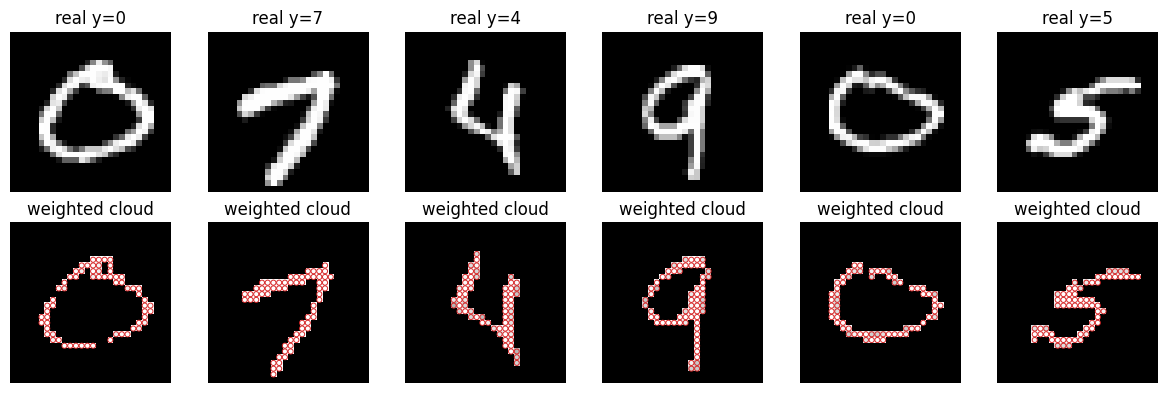

In [7]:
def show_real_reconstructions(batch: WeightedPointCloudBatch, count: int = 6) -> None:
    idx = np.arange(min(count, len(batch)))
    recon = rasterize_weighted_point_clouds(batch.masses[idx], batch.positions[idx])

    fig, axes = plt.subplots(2, len(idx), figsize=(2.0 * len(idx), 4.0))
    for j, i in enumerate(idx):
        axes[0, j].imshow(batch.images[i], cmap='gray')
        axes[0, j].set_title(f'real y={int(batch.labels[i])}')
        axes[0, j].axis('off')

        axes[1, j].imshow(recon[j], cmap='gray')
        axes[1, j].scatter(
            batch.positions[i, :, 0] * 28 - 0.5,
            batch.positions[i, :, 1] * 28 - 0.5,
            s=10 + 220 * batch.masses[i],
            edgecolors='tab:red',
            facecolors='none',
            linewidths=0.7,
        )
        axes[1, j].set_title('weighted cloud')
        axes[1, j].axis('off')
    plt.tight_layout()

show_real_reconstructions(train_pc, count=6)


## Train an auxiliary point-cloud classifier for evaluation

The generator in this notebook uses only the score network below.  We still train a small classifier so we can reuse the same evaluation protocol from Example 6 (`g_accuracy`, CAS, Sinkhorn-based two-sample metrics).


In [8]:
eval_classifier = TerminalSetClassifier(point_feature_dim=128, hidden_dim=256, num_classes=10)
print('training auxiliary classifier with max_tau =', AUX_CLASSIFIER_MAX_TAU)

_ = train_terminal_set_classifier_noisy(
    eval_classifier,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    val_masses=val_pc.masses,
    val_positions=val_pc.positions,
    val_labels=val_pc.labels,
    epochs=AUX_CLASSIFIER_EPOCHS,
    batch_size=AUX_CLASSIFIER_BATCH_SIZE,
    lr=AUX_CLASSIFIER_LR,
    position_jitter_std=2e-3,
    max_tau=AUX_CLASSIFIER_MAX_TAU,
    projection=SCORE_PROJECTION,
    device=DEVICE,
    verbose=True,
)

eval_train_metrics = evaluate_terminal_set_classifier(
    eval_classifier,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    device=DEVICE,
)
eval_val_metrics = evaluate_terminal_set_classifier(
    eval_classifier,
    val_pc.masses,
    val_pc.positions,
    val_pc.labels,
    device=DEVICE,
)

print('aux classifier train accuracy =', eval_train_metrics['accuracy'])
print('aux classifier val accuracy   =', eval_val_metrics['accuracy'])


training auxiliary classifier with max_tau = 0.0005
[terminal noisy] epoch 001/012: train loss = 2.1556, train acc = 0.1817, val loss = 2.1018, val acc = 0.2002
[terminal noisy] epoch 002/012: train loss = 2.0910, train acc = 0.2148, val loss = 2.0211, val acc = 0.2554
[terminal noisy] epoch 003/012: train loss = 2.0539, train acc = 0.2346, val loss = 1.9646, val acc = 0.2476
[terminal noisy] epoch 004/012: train loss = 2.0292, train acc = 0.2395, val loss = 1.9461, val acc = 0.2984
[terminal noisy] epoch 005/012: train loss = 1.9880, train acc = 0.2665, val loss = 1.7362, val acc = 0.3408
[terminal noisy] epoch 006/012: train loss = 1.9011, train acc = 0.3028, val loss = 1.5338, val acc = 0.4258
[terminal noisy] epoch 007/012: train loss = 1.8407, train acc = 0.3267, val loss = 1.2502, val acc = 0.5706
[terminal noisy] epoch 008/012: train loss = 1.7986, train acc = 0.3462, val loss = 1.2137, val acc = 0.5708
[terminal noisy] epoch 009/012: train loss = 1.7682, train acc = 0.3597, val

## Train the denoising score network

The score network receives

- the noisy positions,
- the frozen mass vector,
- the noise level `tau`,
- and the digit label,

and predicts the weighted score field.  The training loss is the weighted denoising score-matching objective from the note.


In [9]:
if SCORE_ARCHITECTURE == 'deepsets':
    score_model = ConditionalScoreSetNetwork(
        point_feature_dim=128,
        hidden_dim=256,
        conditioning_dim=64,
        num_classes=10,
        condition_on_label=True,
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        use_torus_features=(SCORE_PROJECTION == 'wrap'),
        score_output_scaling=SCORE_OUTPUT_SCALING,
    )
elif SCORE_ARCHITECTURE == 'image_field':
    score_model = ConditionalScoreImageFieldNetwork(
        grid_size=SCORE_IMAGE_FIELD_GRID_SIZE,
        base_channels=SCORE_IMAGE_FIELD_BASE_CHANNELS,
        grid_feature_dim=SCORE_IMAGE_FIELD_FEATURE_DIM,
        point_hidden_dim=SCORE_IMAGE_FIELD_POINT_HIDDEN_DIM,
        conditioning_dim=64,
        num_classes=10,
        condition_on_label=True,
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        dropout=SCORE_IMAGE_FIELD_DROPOUT,
        use_torus_features=(SCORE_PROJECTION == 'wrap'),
        score_output_scaling=SCORE_OUTPUT_SCALING,
    )
elif SCORE_ARCHITECTURE == 'set_transformer':
    score_model = ConditionalScoreSetTransformer(
        point_feature_dim=SCORE_TRANSFORMER_POINT_FEATURE_DIM,
        hidden_dim=SCORE_TRANSFORMER_HIDDEN_DIM,
        conditioning_dim=64,
        num_classes=10,
        condition_on_label=True,
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        dropout=SCORE_TRANSFORMER_DROPOUT,
        num_attention_layers=SCORE_TRANSFORMER_NUM_LAYERS,
        num_attention_heads=SCORE_TRANSFORMER_NUM_HEADS,
        use_torus_features=(SCORE_PROJECTION == 'wrap'),
        score_output_scaling=SCORE_OUTPUT_SCALING,
    )
else:
    raise ValueError("SCORE_ARCHITECTURE must be 'deepsets', 'image_field', or 'set_transformer'")

num_score_parameters = sum(p.numel() for p in score_model.parameters())
print(score_model)
print('score model parameters =', f'{num_score_parameters:,}')

score_history = train_score_model(
    score_model,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    val_masses=val_pc.masses,
    val_positions=val_pc.positions,
    val_labels=val_pc.labels,
    epochs=SCORE_EPOCHS,
    batch_size=SCORE_BATCH_SIZE,
    lr=SCORE_LR,
    position_jitter_std=0.0,
    tau_min=TAU_MIN,
    tau_max=TAU_MAX,
    tau_sampling=SCORE_TAU_SAMPLING,
    projection=SCORE_PROJECTION,
    device=DEVICE,
    verbose=True,
)

score_train_metrics = evaluate_score_model(
    score_model,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    batch_size=SCORE_BATCH_SIZE,
    tau_min=TAU_MIN,
    tau_max=TAU_MAX,
    tau_sampling=SCORE_TAU_SAMPLING,
    projection=SCORE_PROJECTION,
    device=DEVICE,
)
score_val_metrics = evaluate_score_model(
    score_model,
    val_pc.masses,
    val_pc.positions,
    val_pc.labels,
    batch_size=SCORE_BATCH_SIZE,
    tau_min=TAU_MIN,
    tau_max=TAU_MAX,
    tau_sampling=SCORE_TAU_SAMPLING,
    projection=SCORE_PROJECTION,
    device=DEVICE,
)

print('score train loss =', score_train_metrics['loss'])
print('score val loss   =', score_val_metrics['loss'])
print('score train zero baseline =', score_train_metrics.get('zero_predictor_loss'))
print('score val zero baseline   =', score_val_metrics.get('zero_predictor_loss'))
print('score val fraction improved over zero =', score_val_metrics.get('fraction_improved_over_zero'))


ConditionalScoreImageFieldNetwork(
  (time_mlp): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): GELU(approximate='none')
  )
  (label_embedding): Embedding(10, 64)
  (feature_unet): _SmallUNet2d(
    (enc1): _ConvBlock2d(
      (net): Sequential(
        (0): Conv2d(130, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=circular)
        (1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (2): GELU(approximate='none')
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=circular)
        (4): GroupNorm(8, 32, eps=1e-05, affine=True)
        (5): GELU(approximate='none')
      )
    )
    (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (enc2): _ConvBlock2d(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False

In [10]:
score_tau_diagnostics = evaluate_score_model_by_tau_bins(
    score_model,
    val_pc.masses,
    val_pc.positions,
    val_pc.labels,
    batch_size=SCORE_BATCH_SIZE,
    tau_min=TAU_MIN,
    tau_max=TAU_MAX,
    num_bins=8,
    projection=SCORE_PROJECTION,
    device=DEVICE,
)
score_tau_diagnostics_df = pd.DataFrame(score_tau_diagnostics)
score_tau_diagnostics_df


,tau,loss,sample_loss,zero_predictor_loss,fraction_improved_over_zero,median_noise_std,median_noise_pixels,num_points
0,0.000005,95.155884,9.515589e+06,127.826798,0.255587,0.025286,0.708006,64.0
1,0.000010,90.082222,4.665786e+06,127.391355,0.292870,0.035135,0.983771,64.0
2,0.000019,86.377367,2.317242e+06,127.859032,0.324433,0.048819,1.366946,64.0
3,0.000036,83.490442,1.160096e+06,127.858488,0.347009,0.067834,1.899365,64.0
4,0.000069,81.722937,5.881483e+05,127.856718,0.360824,0.094256,2.639159,64.0
5,0.000134,81.557823,3.040144e+05,126.410262,0.354816,0.130968,3.667100,64.0
6,0.000259,73.377854,1.416705e+05,108.681680,0.324837,0.181979,5.095419,64.0
7,0.000500,37.551859,3.755186e+04,55.325772,0.321259,0.252859,7.080062,64.0


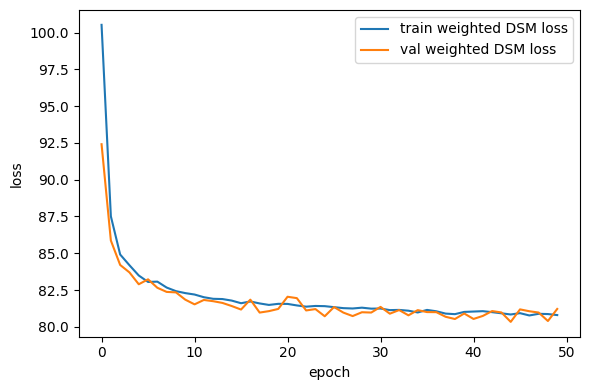

In [11]:
fig = plt.figure(figsize=(6, 4))
plt.plot(score_history['train_loss'], label='train weighted DSM loss')
plt.plot(score_history['val_loss'], label='val weighted DSM loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()


## Generate synthetic weighted point clouds

By default the mass vectors are sampled from the empirical training bank, which matches the statement that `rho_0` is the empirical MNIST distribution in weighted-point-cloud form.  You can switch `MASS_SAMPLING_MODE` to `'truncated_poisson_dirichlet'` to explore out-of-bank masses, just as in the more generative ablation of Example 6.

The reverse sampler uses the Euler--Maruyama drift `2 * SCORE_SCALE * S_theta` directly.  No drift clipping is applied.  The default projection is now `wrap`, matching the torus/modulo state space in the PDF and avoiding the large-noise reflection-score mismatch that occurs with `reflect`.


In [ ]:
initial_position_bank = train_pc.positions if INITIAL_POSITION_MODE == 'bank' else None
initial_position_bank_labels = train_pc.labels if INITIAL_POSITION_MODE == 'bank' else None
mass_bank = train_pc.masses if MASS_SAMPLING_MODE == 'bank' else None
mass_bank_labels = train_pc.labels if MASS_SAMPLING_MODE == 'bank' else None

synthetic = generate_balanced_score_matching_dataset(
    score_model,
    mass_bank,
    bank_labels=mass_bank_labels,
    num_points=TOP_K,
    num_per_class=SYNTHETIC_PER_CLASS,
    mass_sampling_mode=MASS_SAMPLING_MODE,
    class_conditional_mass_sampling=CLASS_CONDITIONAL_MASS_SAMPLING,
    poisson_dirichlet_beta=POISSON_DIRICHLET_BETA,
    poisson_dirichlet_max_terms=POISSON_DIRICHLET_MAX_TERMS,
    horizon=HORIZON,
    step_size=STEP_SIZE,
    initial_position_mode=INITIAL_POSITION_MODE,
    initial_position_scale=INITIAL_POSITION_SCALE,
    initial_position_bank=initial_position_bank,
    initial_position_bank_labels=initial_position_bank_labels,
    class_conditional_initial_positions=CLASS_CONDITIONAL_INITIAL_POSITIONS,
    joint_bank_sampling=JOINT_BANK_SAMPLING,
    initial_position_jitter=INITIAL_POSITION_JITTER,
    state_projection=SCORE_PROJECTION,
    diffusion_temperature=DIFFUSION_TEMPERATURE,
    score_scale=SCORE_SCALE,
    sampler_scheme=SAMPLER_SCHEME,   # <-- missing in main generation
    batch_size=64,
    rasterize=True,
    image_size=28,
    device=DEVICE,
    rng=np.random.default_rng(SEED),
)

print('synthetic positions:', synthetic.positions.shape)
print('synthetic images   :', synthetic.images.shape)


synthetic positions: (10000, 64, 2)
synthetic images   : (10000, 28, 28)


### Optional forward-noised-bank sanity check

This is not the final independent generator. It starts from empirical point clouds noised with the exact mass-dependent kernel at `tau=HORIZON`. Use it to check whether the learned reverse dynamics work when the initial law is known to match score training.


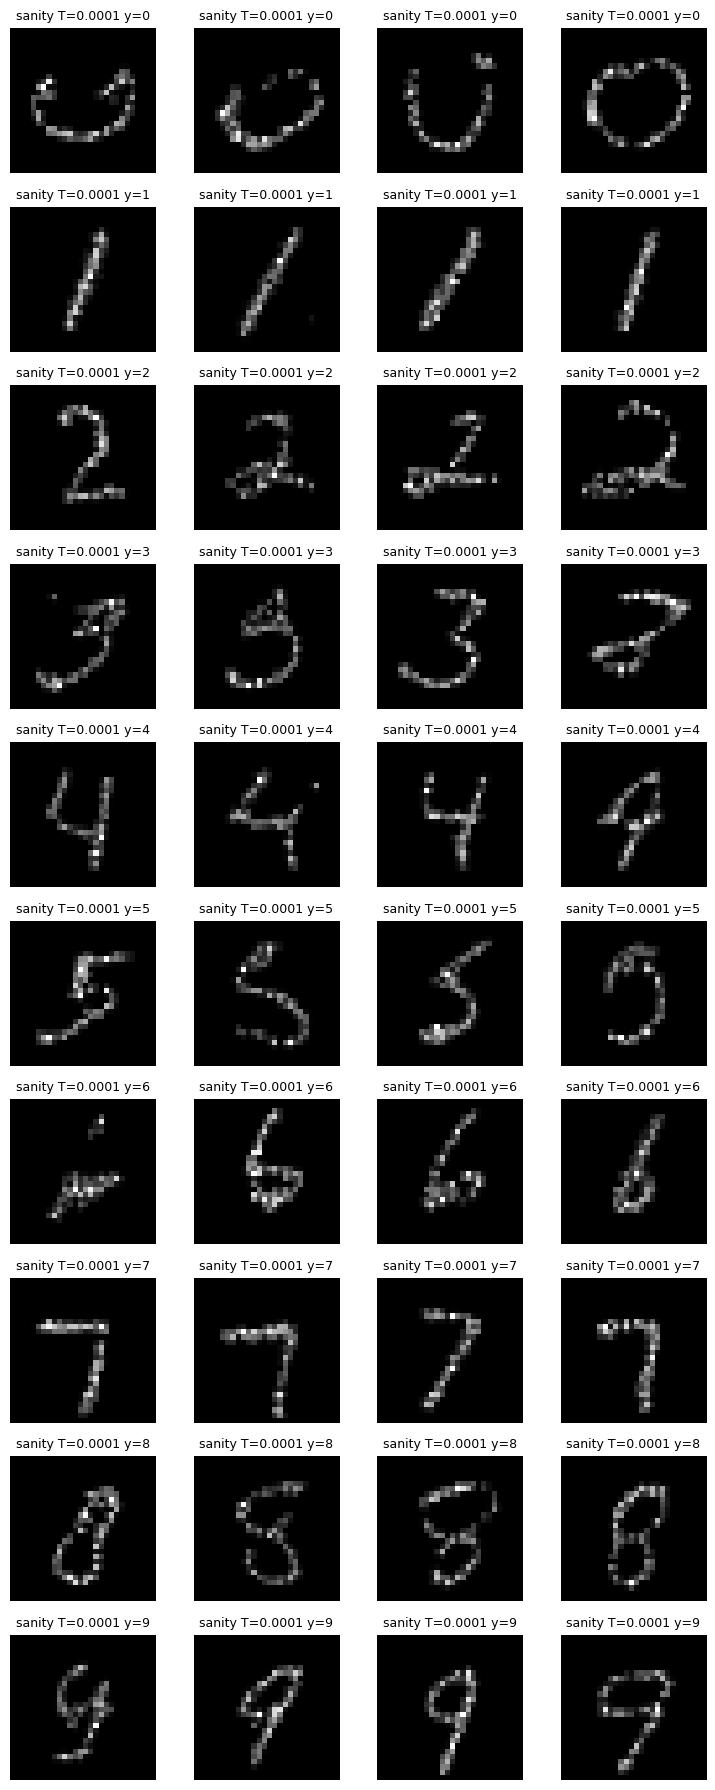

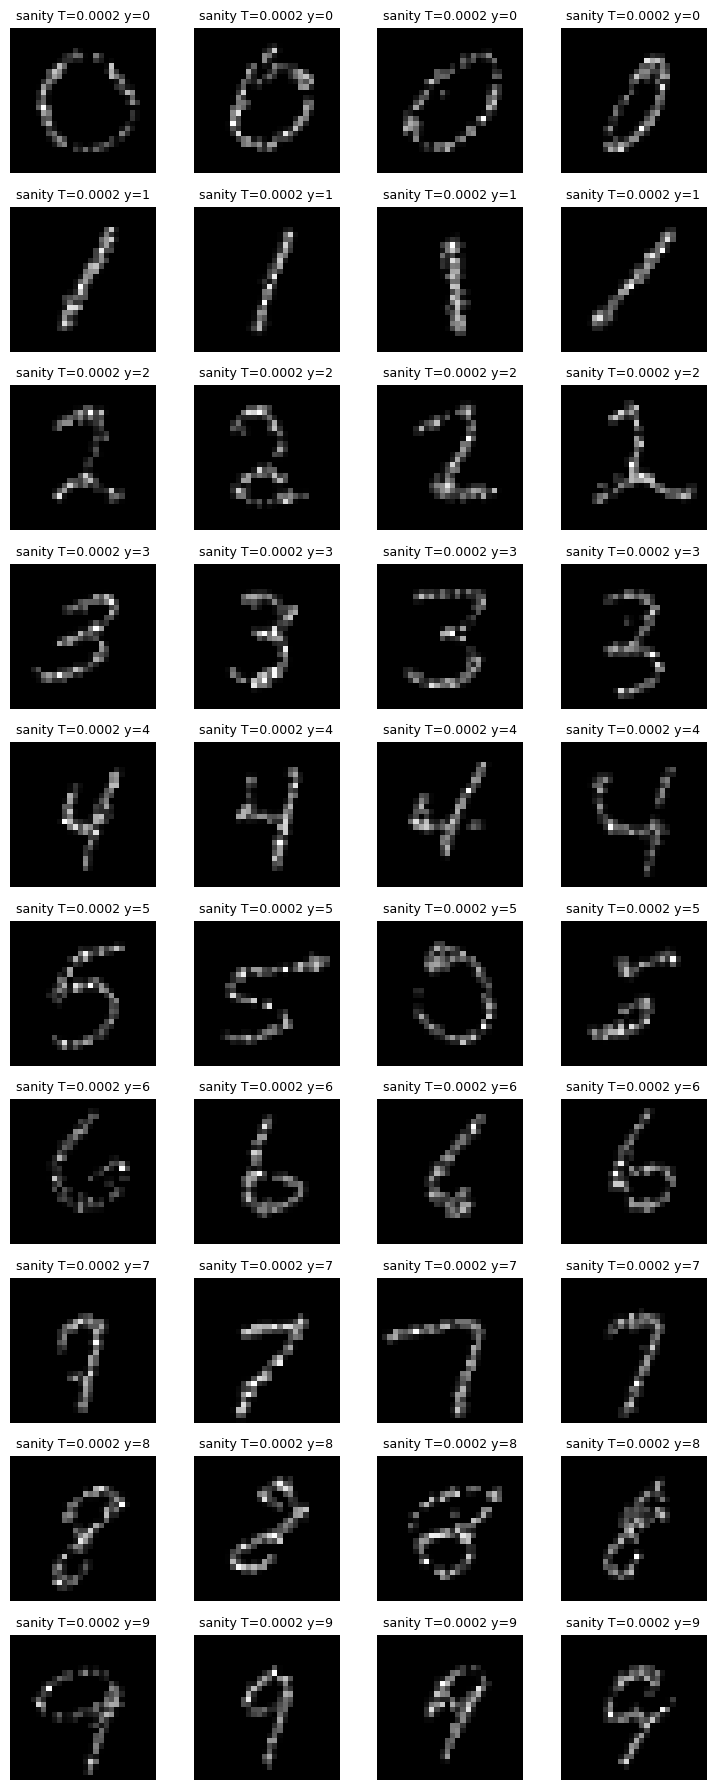

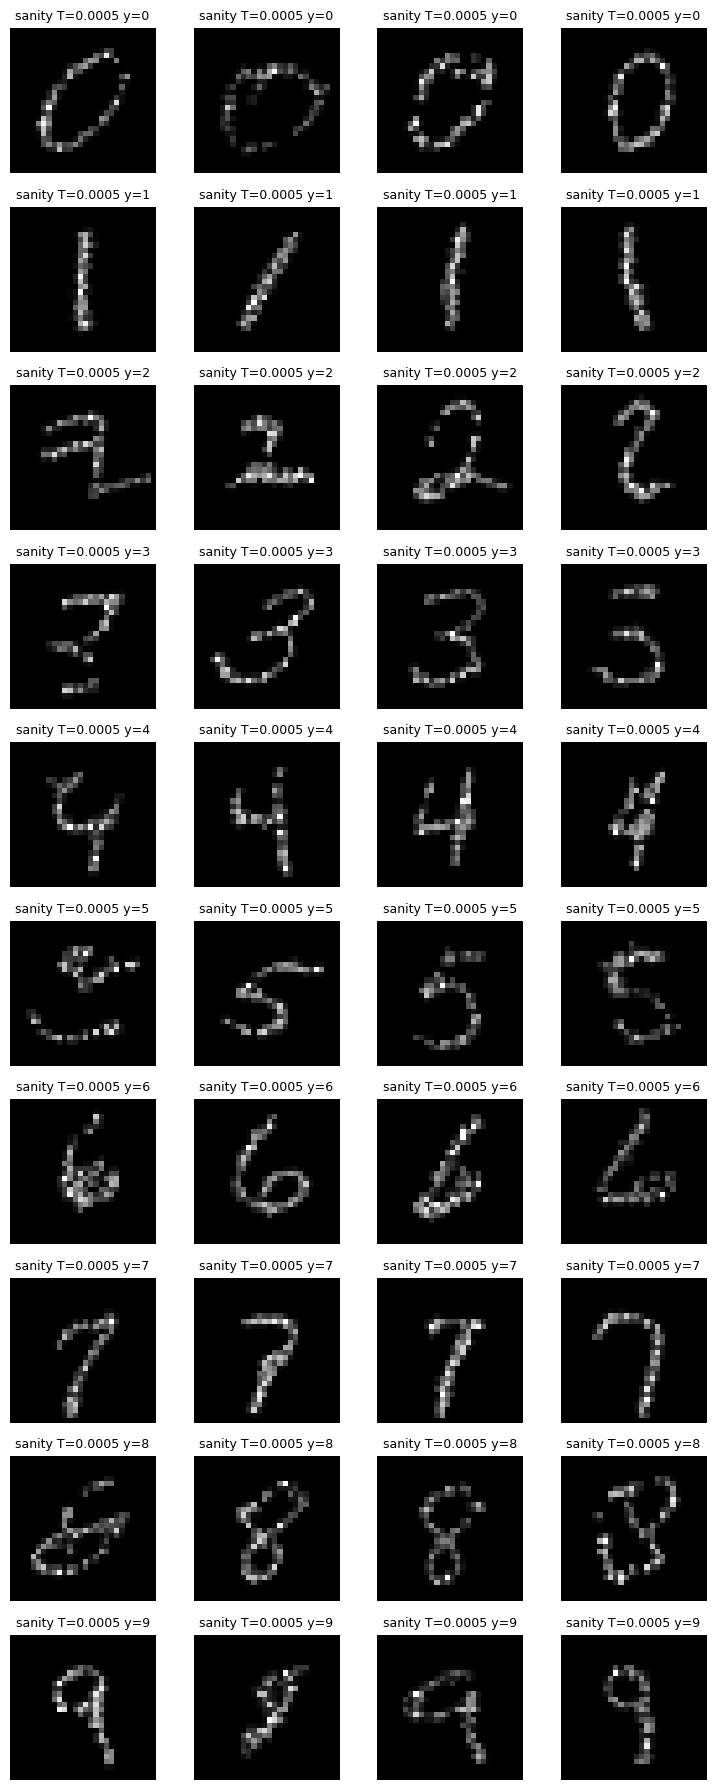

In [13]:
for H in [1e-4, 2e-4, 5e-4]:
    sanity = generate_balanced_score_matching_dataset(
        score_model,
        train_pc.masses,
        bank_labels=train_pc.labels,
        num_per_class=64,
        mass_sampling_mode="bank",
        class_conditional_mass_sampling=True,
        horizon=H,
        step_size=5e-6,
        initial_position_mode="forward_noised_bank",
        initial_position_bank=train_pc.positions,
        initial_position_bank_labels=train_pc.labels,
        state_projection=SCORE_PROJECTION,
        diffusion_temperature=1.0,
        sampler_scheme=SAMPLER_SCHEME,
        score_scale=1.0,
        batch_size=SCORE_BATCH_SIZE,
        device=DEVICE,
        rng=np.random.default_rng(SEED + int(H * 1e7)),
    )
    show_synthetic_examples(sanity, count_per_class=4, title_prefix=f"sanity T={H}")

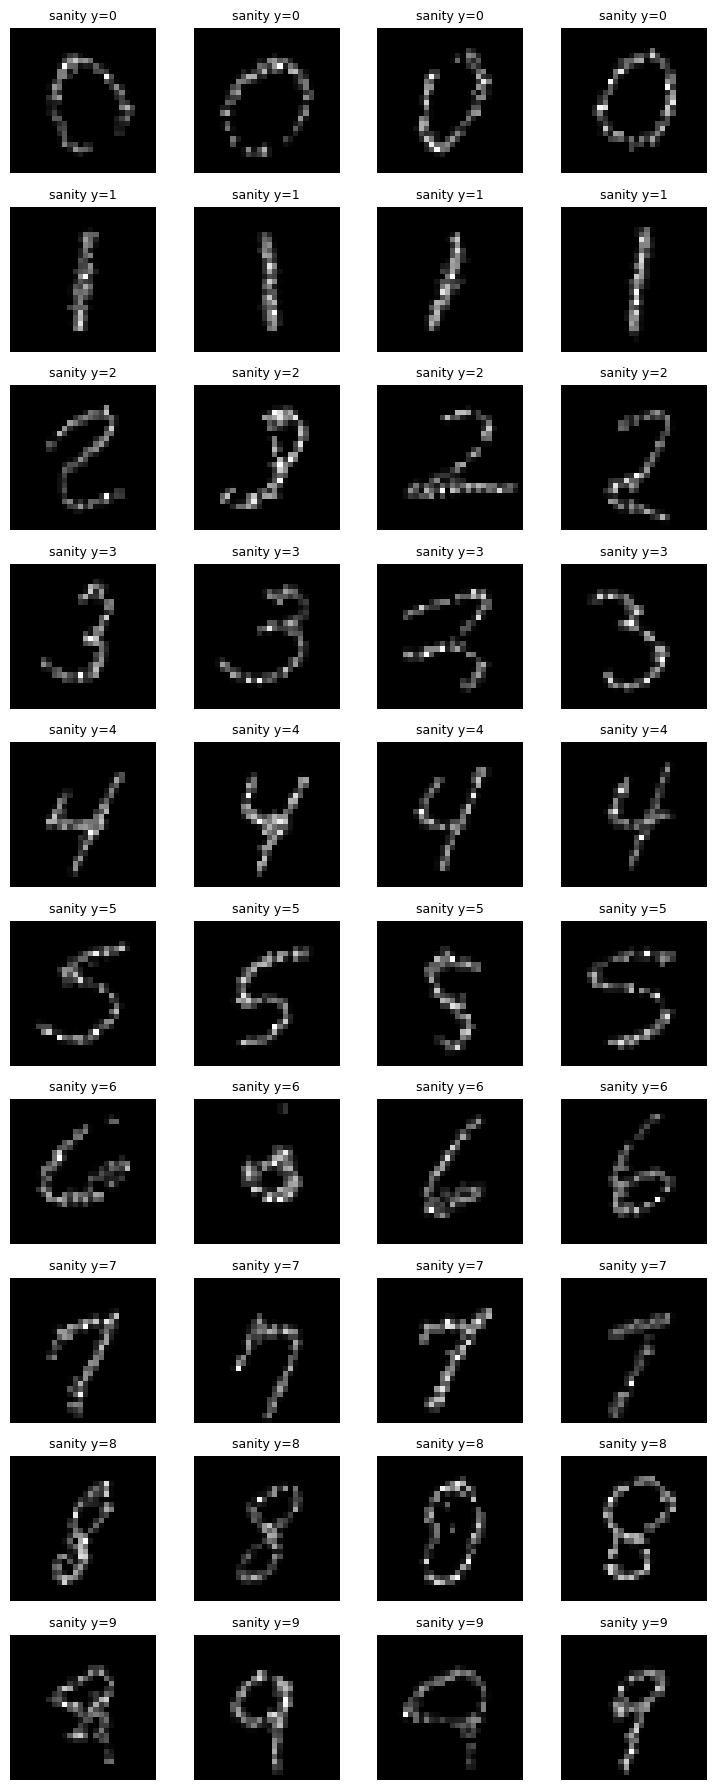

In [14]:
if RUN_FORWARD_NOISED_BANK_SANITY_CHECK:
    forward_noised_bank_sanity = generate_balanced_score_matching_dataset(
        score_model,
        train_pc.masses,
        bank_labels=train_pc.labels,
        num_points=TOP_K,
        num_per_class=FORWARD_NOISED_BANK_SYNTHETIC_PER_CLASS,
        mass_sampling_mode='bank',
        class_conditional_mass_sampling=CLASS_CONDITIONAL_MASS_SAMPLING,
        horizon=HORIZON,
        step_size=STEP_SIZE,
        initial_position_mode='forward_noised_bank',
        initial_position_bank=train_pc.positions,
        initial_position_bank_labels=train_pc.labels,
        state_projection=SCORE_PROJECTION,
        diffusion_temperature=DIFFUSION_TEMPERATURE,
        score_scale=SCORE_SCALE,
        batch_size=64,
        rasterize=True,
        image_size=28,
        sampler_scheme=SAMPLER_SCHEME,
        device=DEVICE,
        rng=np.random.default_rng(SEED + 123),
    )
    show_synthetic_examples(forward_noised_bank_sanity, count_per_class=4, title_prefix='sanity')
else:
    forward_noised_bank_sanity = None


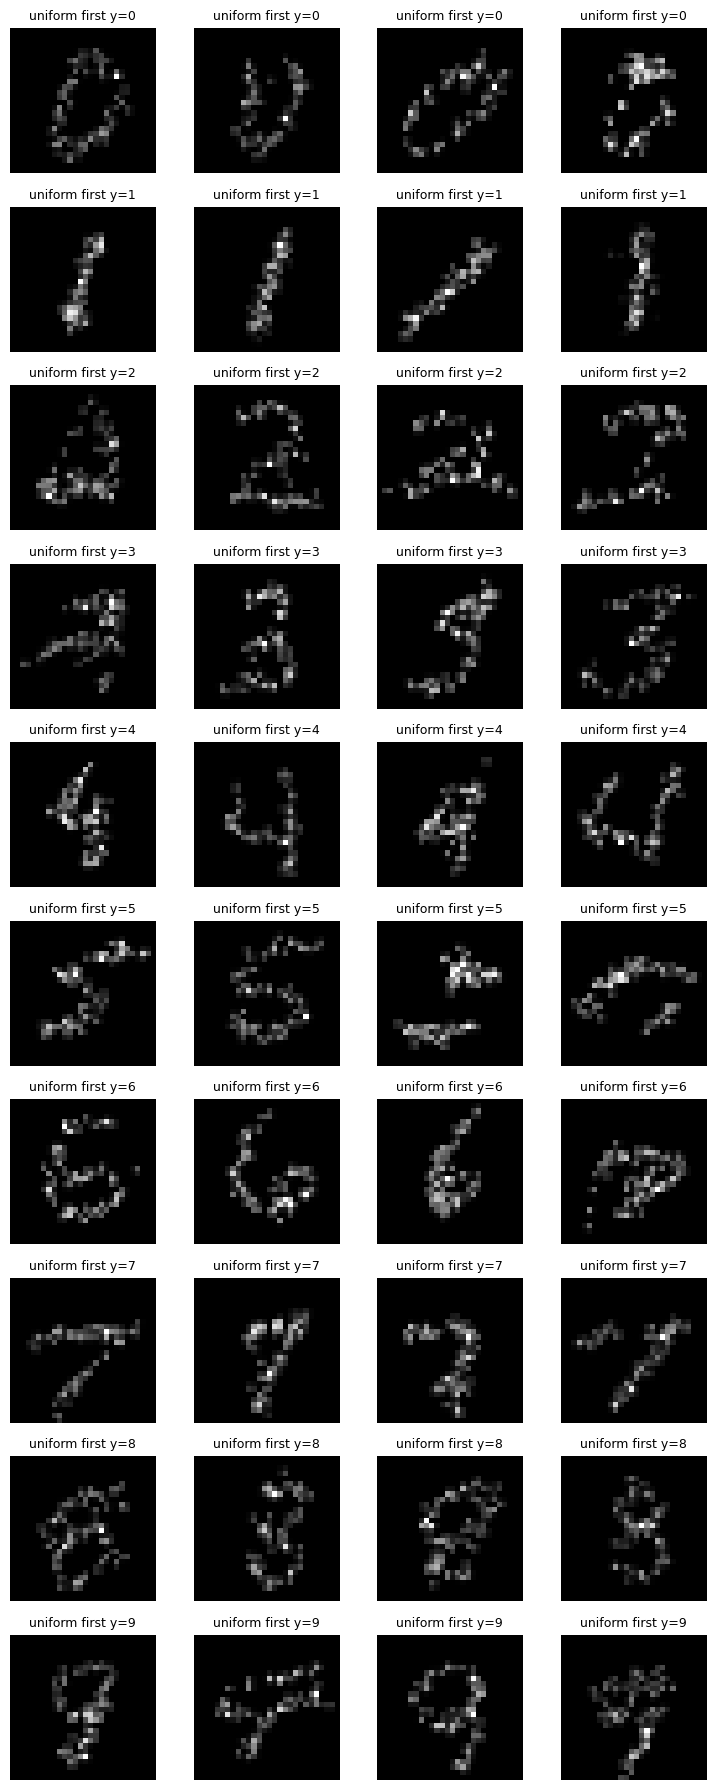

In [15]:
show_synthetic_examples(synthetic, count_per_class=4, title_prefix='uniform first', selection='first')


# One-stop denoising diagnostic
The reverse sampler is stochastic, so it can hide whether the score itself is good. Add a direct diagnostic:
\(\hat{X} = Y + 2\tau S_{\theta}(\tau,s, Y) \)

If this one-step denoising is bad, the score model is the bottleneck. If this is good but the reverse sampler is bad, the sampler/noise schedule is the bottleneck.

In [16]:
from mnist.score_matching import perturb_weighted_point_cloud_positions
from mnist.weighted_point_cloud import rasterize_weighted_point_clouds
from mnist.conditioned_diffusion import project_positions

@torch.no_grad()
def one_step_denoising_samples(
    model,
    masses_np,
    positions_np,
    labels_np,
    *,
    tau_value,
    count=64,
    projection="wrap",
    device=DEVICE,
):
    model.eval()
    idx = np.arange(min(count, len(labels_np)))

    masses = torch.tensor(masses_np[idx], dtype=torch.float32, device=device)
    clean = torch.tensor(positions_np[idx], dtype=torch.float32, device=device)
    labels = torch.tensor(labels_np[idx], dtype=torch.long, device=device)
    tau = torch.full((len(idx),), float(tau_value), dtype=torch.float32, device=device)

    noisy, target_score, _ = perturb_weighted_point_cloud_positions(
        masses,
        clean,
        tau,
        projection=projection,
    )

    pred_score = model(masses, noisy, tau, labels)

    # Tweedie-style denoising displacement.
    denoised = noisy + 2.0 * tau[:, None, None] * pred_score
    denoised = project_positions(denoised, mode=projection)

    masses_np_out = masses.detach().cpu().numpy()
    clean_np = clean.detach().cpu().numpy()
    noisy_np = noisy.detach().cpu().numpy()
    denoised_np = denoised.detach().cpu().numpy()

    clean_img = rasterize_weighted_point_clouds(
        masses_np_out, project_positions(clean_np, mode="clip"), image_size=28
    )
    noisy_img = rasterize_weighted_point_clouds(
        masses_np_out, project_positions(noisy_np, mode="clip"), image_size=28
    )
    denoised_img = rasterize_weighted_point_clouds(
        masses_np_out, project_positions(denoised_np, mode="clip"), image_size=28
    )

    return clean_img, noisy_img, denoised_img, labels_np[idx]

def plot_one_step_denoising_diagnostic(
    clean_img,
    noisy_img,
    denoised_img,
    labels_used,
    *,
    examples_per_label=2,
    max_labels=10,
    sort_labels=True,
    figsize_per_panel=1.8,
    title=None,
):
    """
    Plot one-step denoising diagnostic as rows of:
        Clean | Noisy | Denoised

    Parameters
    ----------
    clean_img : np.ndarray, shape (N, H, W)
    noisy_img : np.ndarray, shape (N, H, W)
    denoised_img : np.ndarray, shape (N, H, W)
    labels_used : array-like, shape (N,)
    examples_per_label : int
        Number of examples to show per label.
    max_labels : int
        Maximum number of distinct labels to include.
    sort_labels : bool
        Whether to sort labels ascending.
    figsize_per_panel : float
        Controls overall figure size.
    title : str or None
        Optional figure title.
    """
    labels_used = np.asarray(labels_used)

    unique_labels = np.unique(labels_used)
    if sort_labels:
        unique_labels = np.sort(unique_labels)
    unique_labels = unique_labels[:max_labels]

    selected_indices = []
    for y in unique_labels:
        idx = np.where(labels_used == y)[0][:examples_per_label]
        selected_indices.extend(idx.tolist())

    if len(selected_indices) == 0:
        print("No samples selected for plotting.")
        return

    n_rows = len(selected_indices)
    n_cols = 3

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * figsize_per_panel, n_rows * figsize_per_panel),
        squeeze=False,
    )

    col_titles = ["Clean", "Noisy", "Denoised"]
    for j in range(n_cols):
        axes[0, j].set_title(col_titles[j])

    for row, idx in enumerate(selected_indices):
        images = [clean_img[idx], noisy_img[idx], denoised_img[idx]]
        y = labels_used[idx]

        for col, img in enumerate(images):
            ax = axes[row, col]
            ax.imshow(img, cmap="gray", interpolation="nearest")
            ax.set_xticks([])
            ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(f"y={y}", rotation=0, labelpad=20, va="center")

    if title is not None:
        fig.suptitle(title, y=1.02)

    plt.tight_layout()
    plt.show()

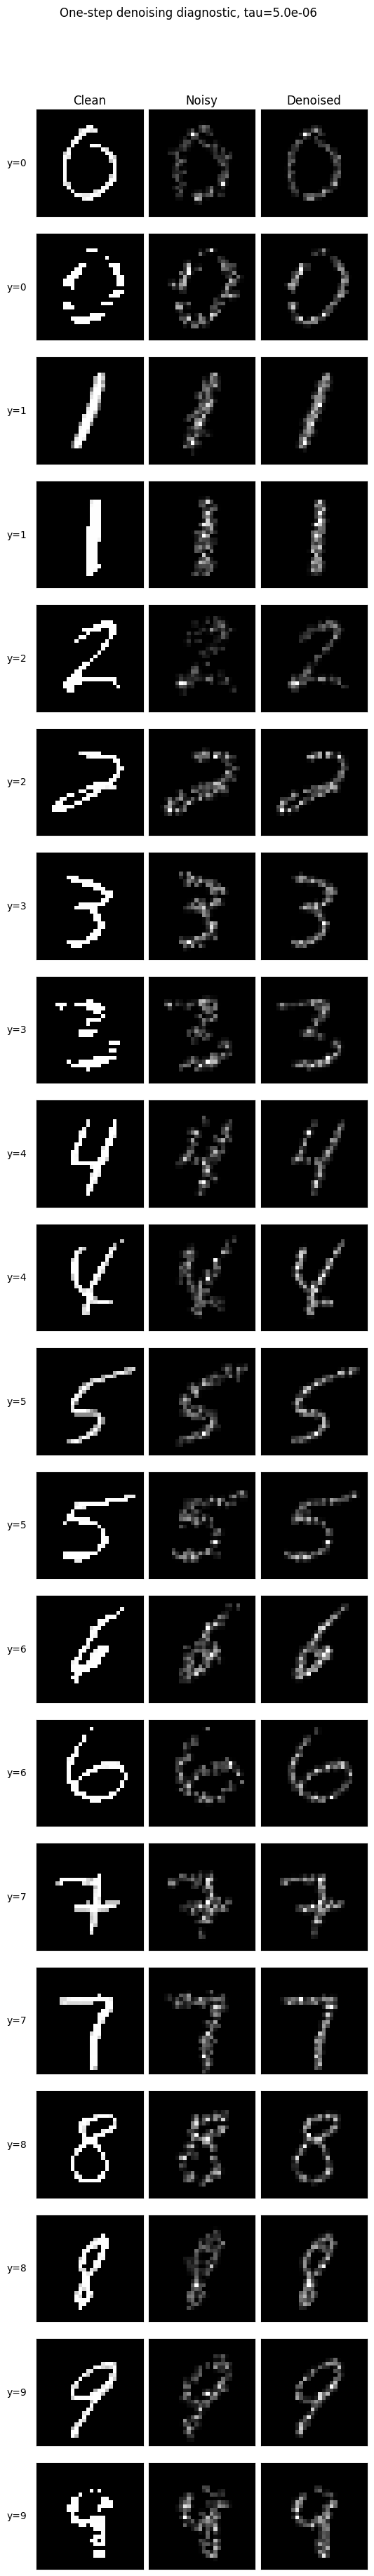

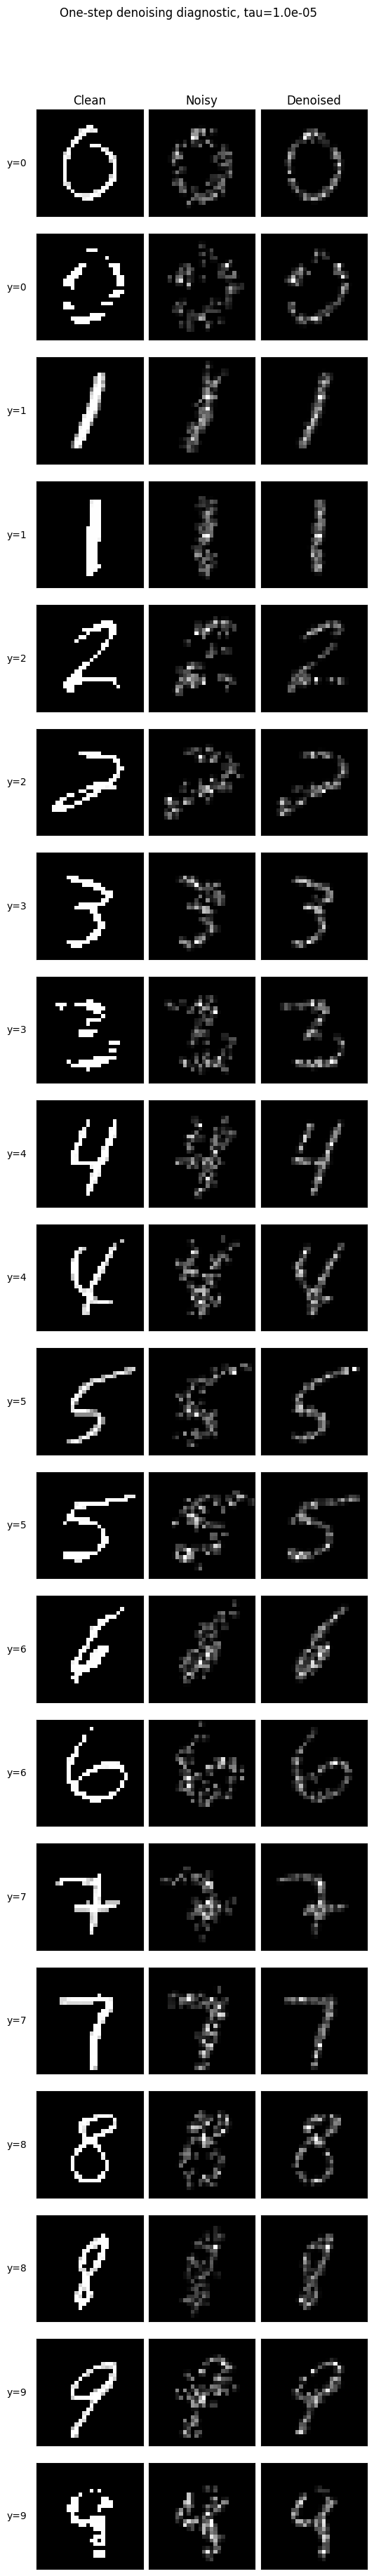

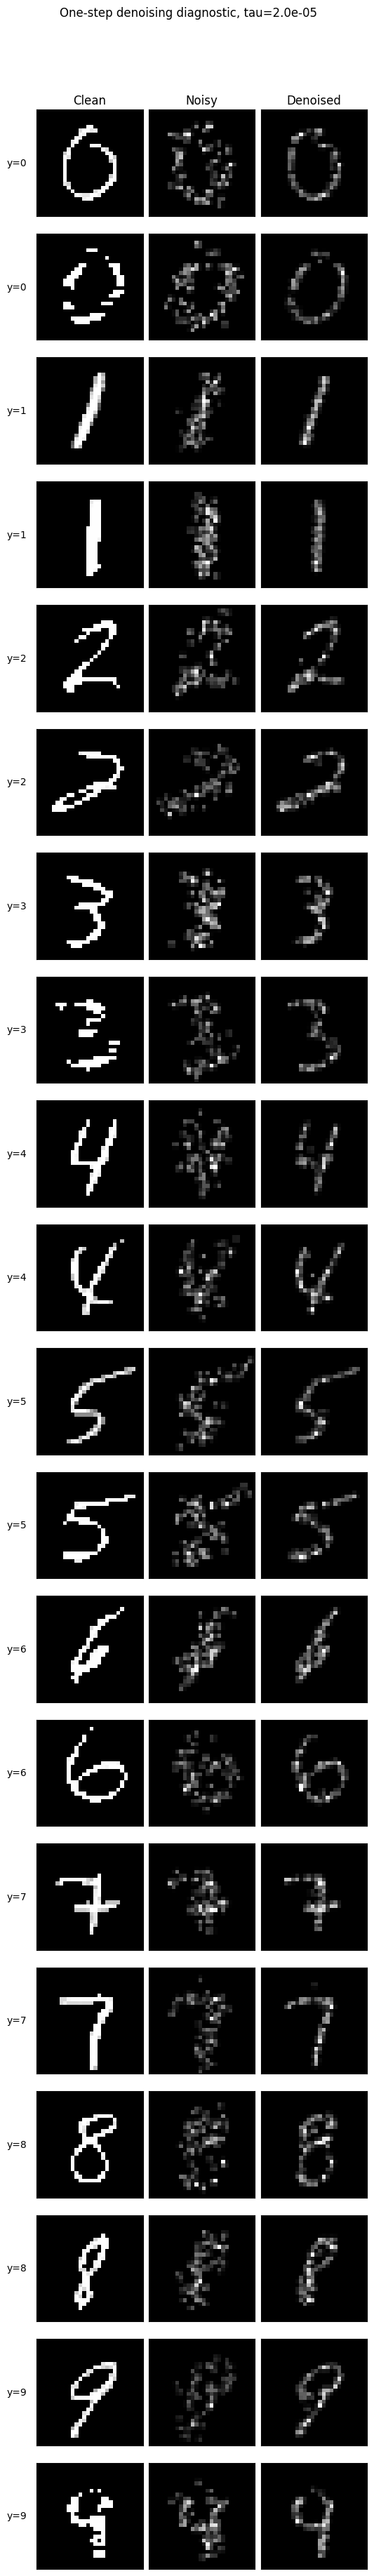

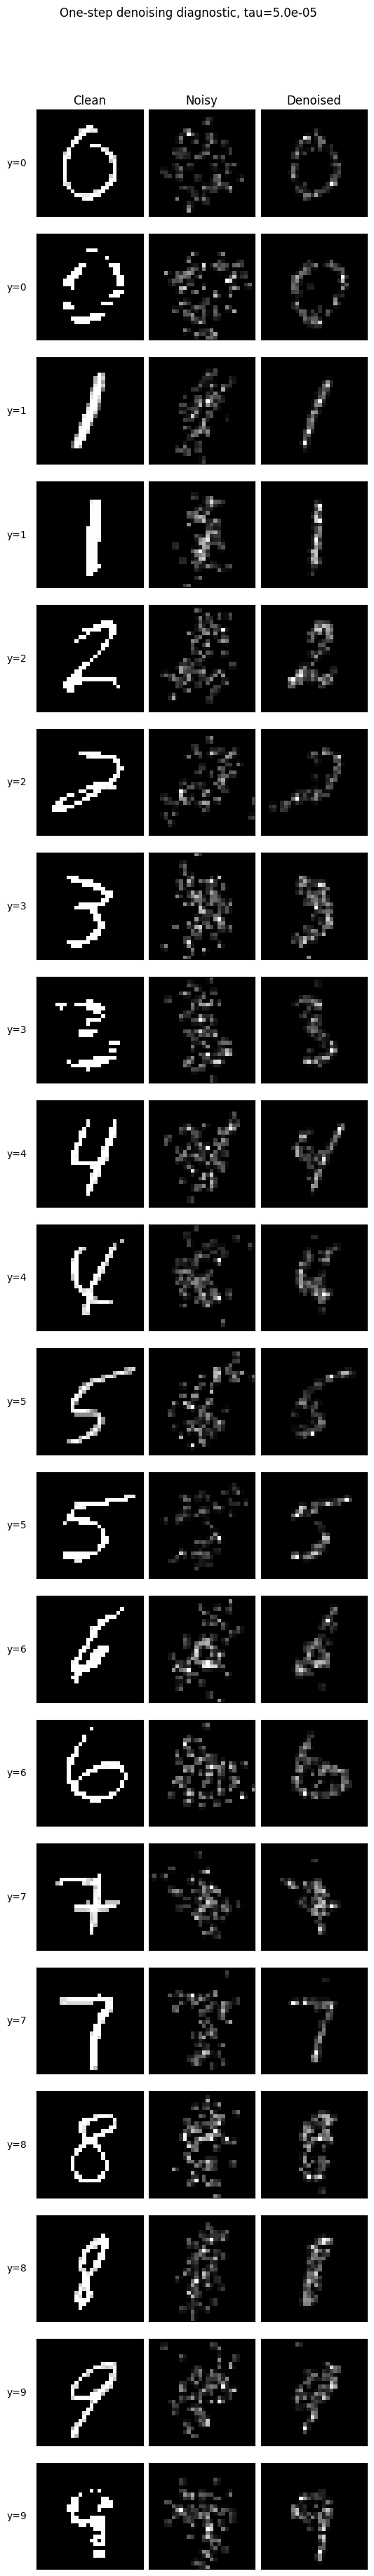

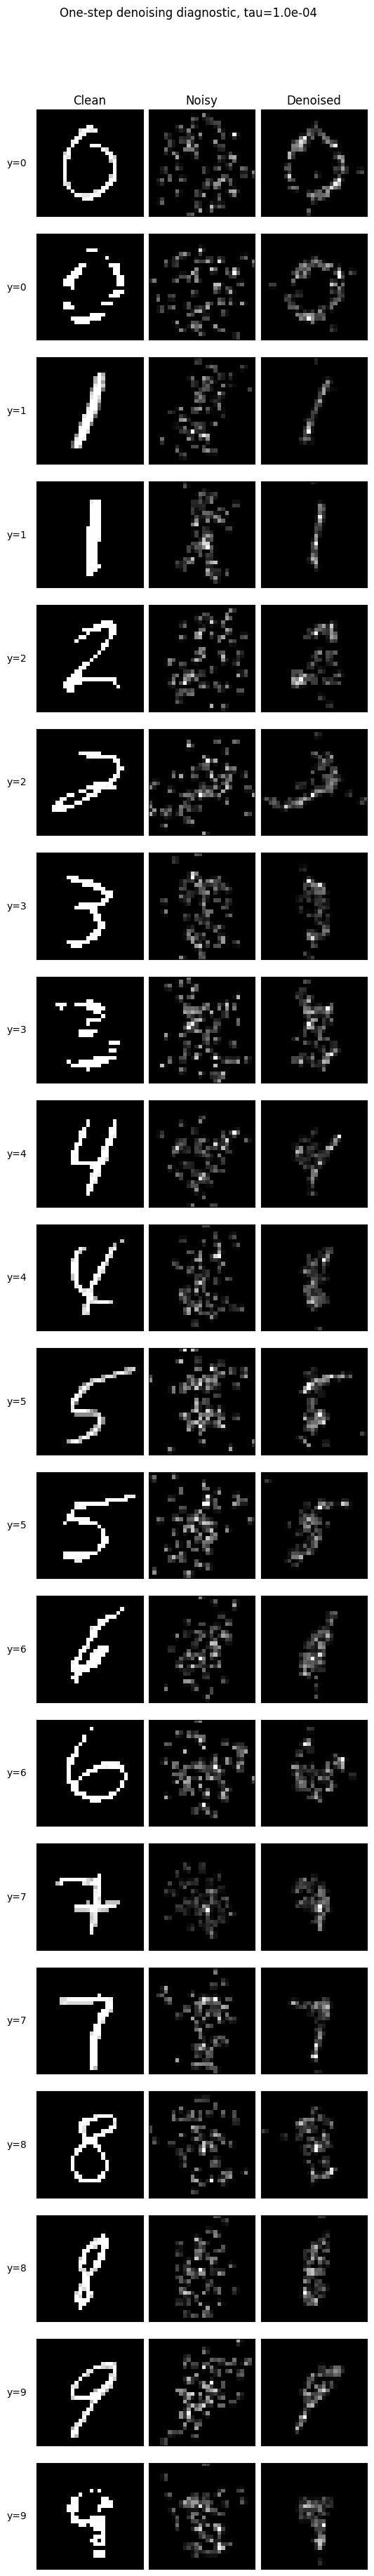

In [17]:
for tau_value in [5e-6, 1e-5, 2e-5, 5e-5, 1e-4]:
    clean_img, noisy_img, denoised_img, labels_used = one_step_denoising_samples(
        score_model,
        val_pc.masses,
        val_pc.positions,
        val_pc.labels,
        tau_value=tau_value,
        count=64,
        projection=SCORE_PROJECTION,
    )
    plot_one_step_denoising_diagnostic(
    clean_img,
    noisy_img,
    denoised_img,
    labels_used,
    examples_per_label=2,
    title=f"One-step denoising diagnostic, tau={tau_value:.1e}",
)

### Visual diagnostics

The first gallery is deterministic: it shows the first generated samples in class order.  The diagnostics below also show random samples, high-confidence samples, and low-confidence samples according to the auxiliary point-cloud classifier.


,label,aux_accuracy,mean_target_probability,median_target_probability
0,0,0.886,0.691697,0.765929
1,1,0.952,0.911513,0.997933
2,2,0.621,0.458421,0.452429
3,3,0.647,0.444381,0.462568
4,4,0.653,0.519870,0.554519
5,5,0.343,0.265833,0.214644
6,6,0.548,0.443402,0.426936
7,7,0.762,0.618019,0.711276
8,8,0.175,0.164468,0.142507
9,9,0.483,0.363658,0.357705


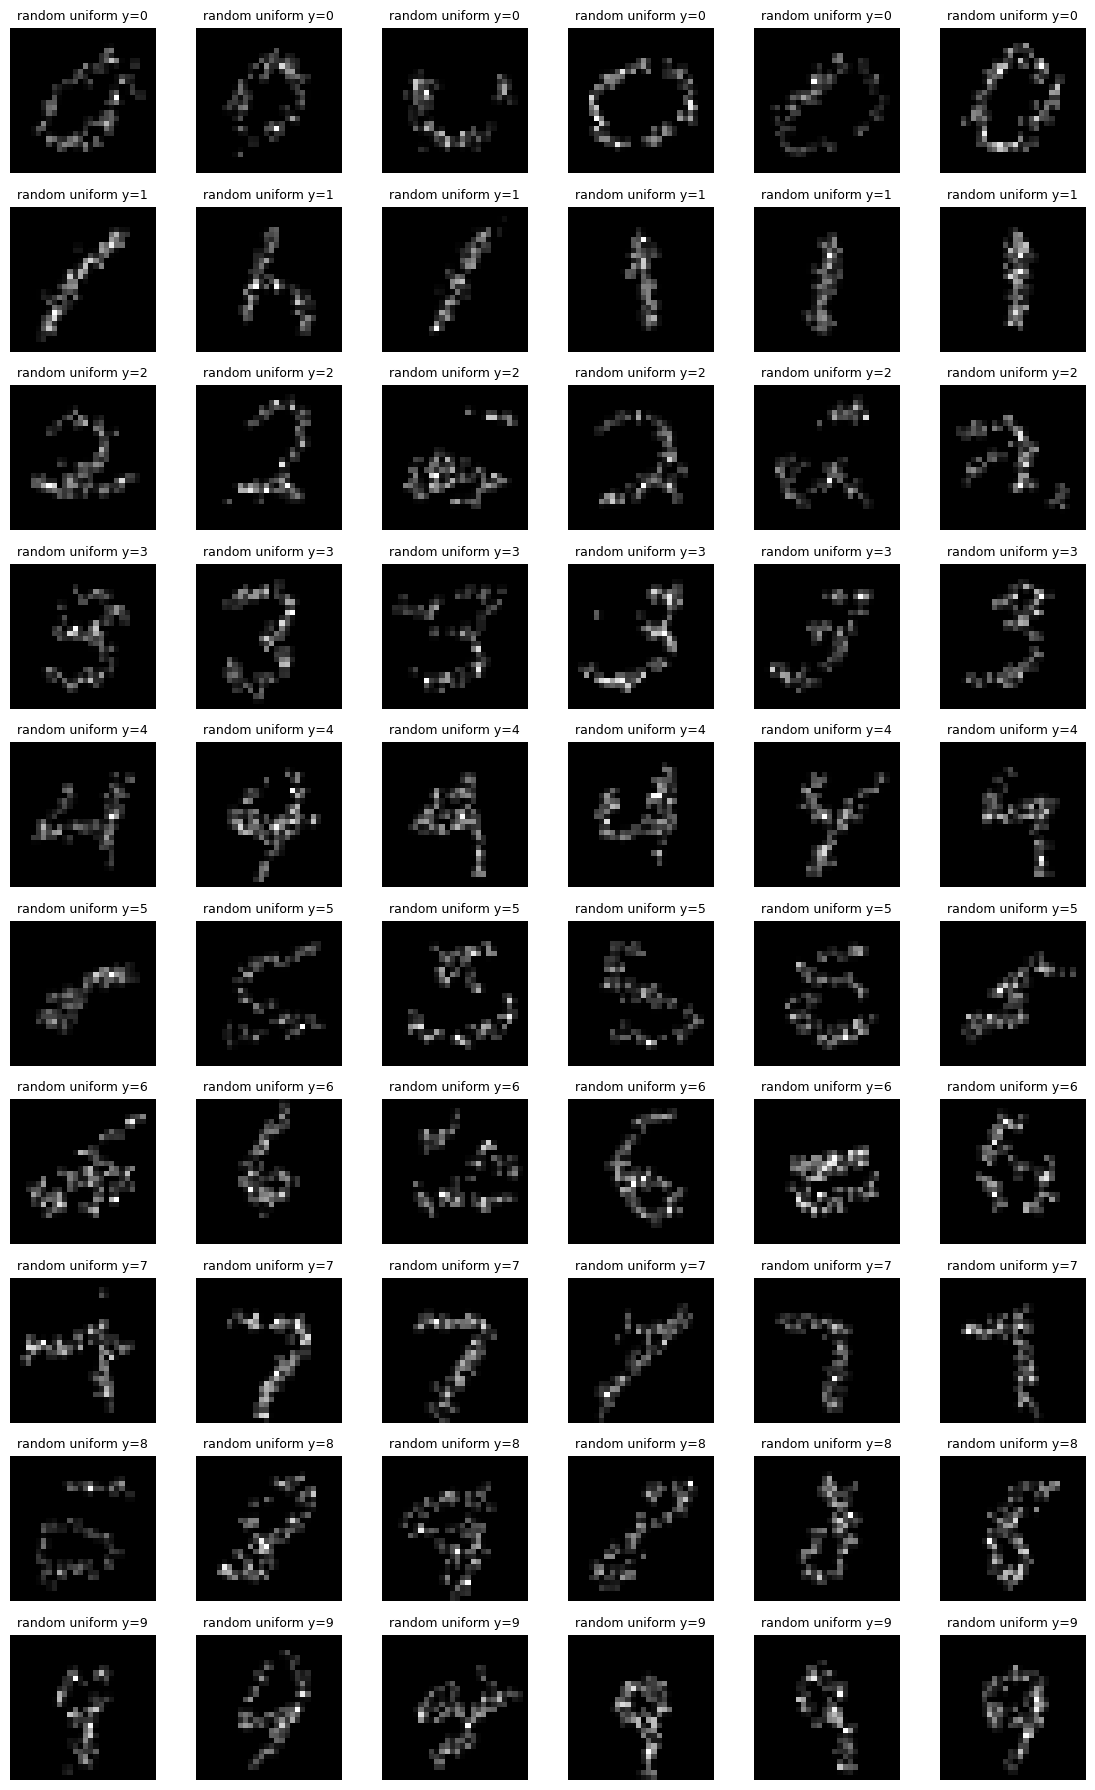

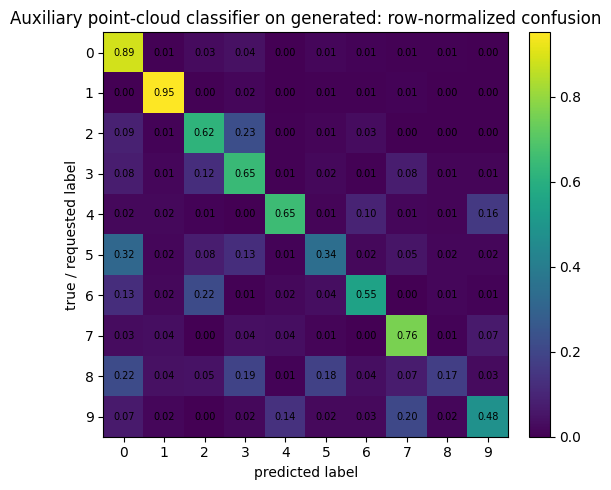

In [18]:
show_synthetic_examples(
    synthetic,
    count_per_class=VISUAL_DIAGNOSTIC_SAMPLES_PER_CLASS,
    title_prefix='random uniform',
    selection='random',
    rng=np.random.default_rng(SEED + 501),
)

aux_visual_diagnostics_df = generated_auxiliary_classifier_diagnostics(eval_classifier, synthetic, device=DEVICE)
aux_target_probability = aux_visual_diagnostics_df['aux_target_probability'].to_numpy()

aux_visual_summary = aux_visual_diagnostics_df.groupby('label').agg(
    aux_accuracy=('aux_correct', 'mean'),
    mean_target_probability=('aux_target_probability', 'mean'),
    median_target_probability=('aux_target_probability', 'median'),
).reset_index()

aux_confusion_true = confusion_matrix_from_predictions(
    synthetic.labels,
    aux_visual_diagnostics_df['aux_prediction'].to_numpy(),
    num_classes=10,
    normalize='true',
)
plot_confusion_matrix(aux_confusion_true, title='Auxiliary point-cloud classifier on generated: row-normalized confusion')
aux_visual_summary


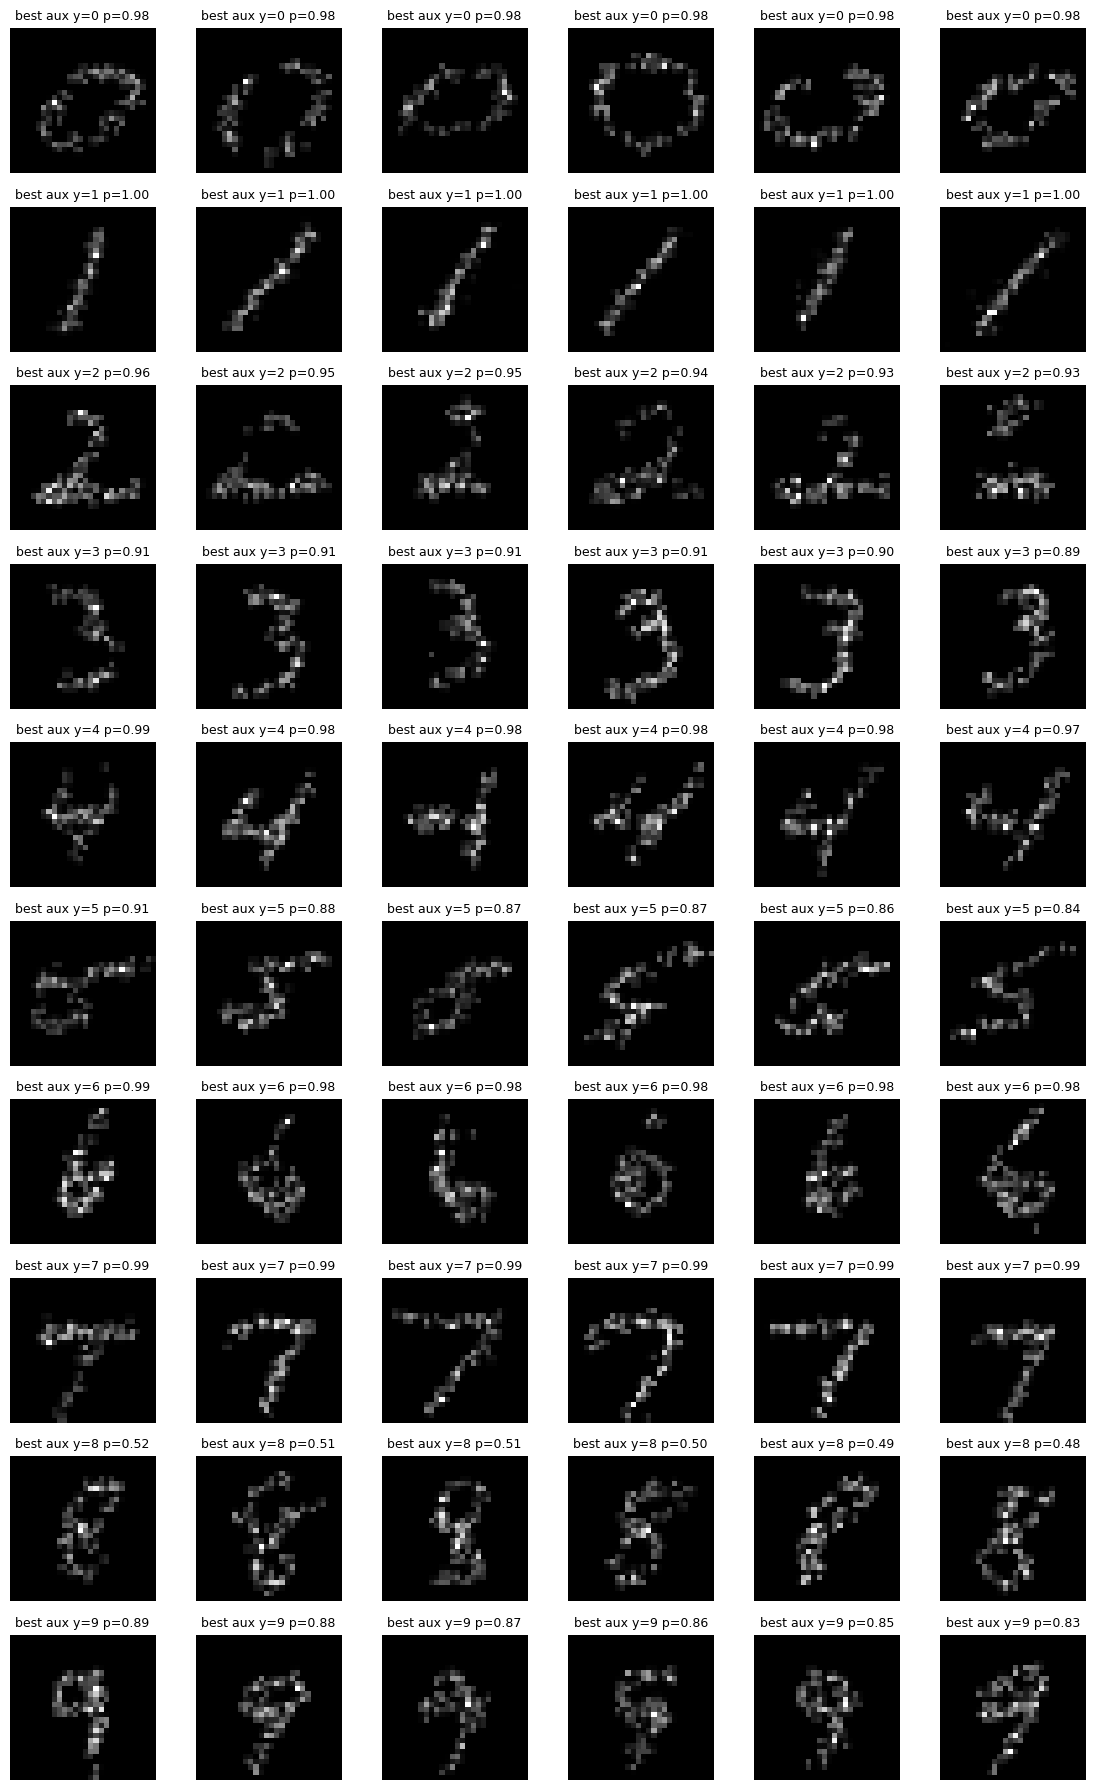

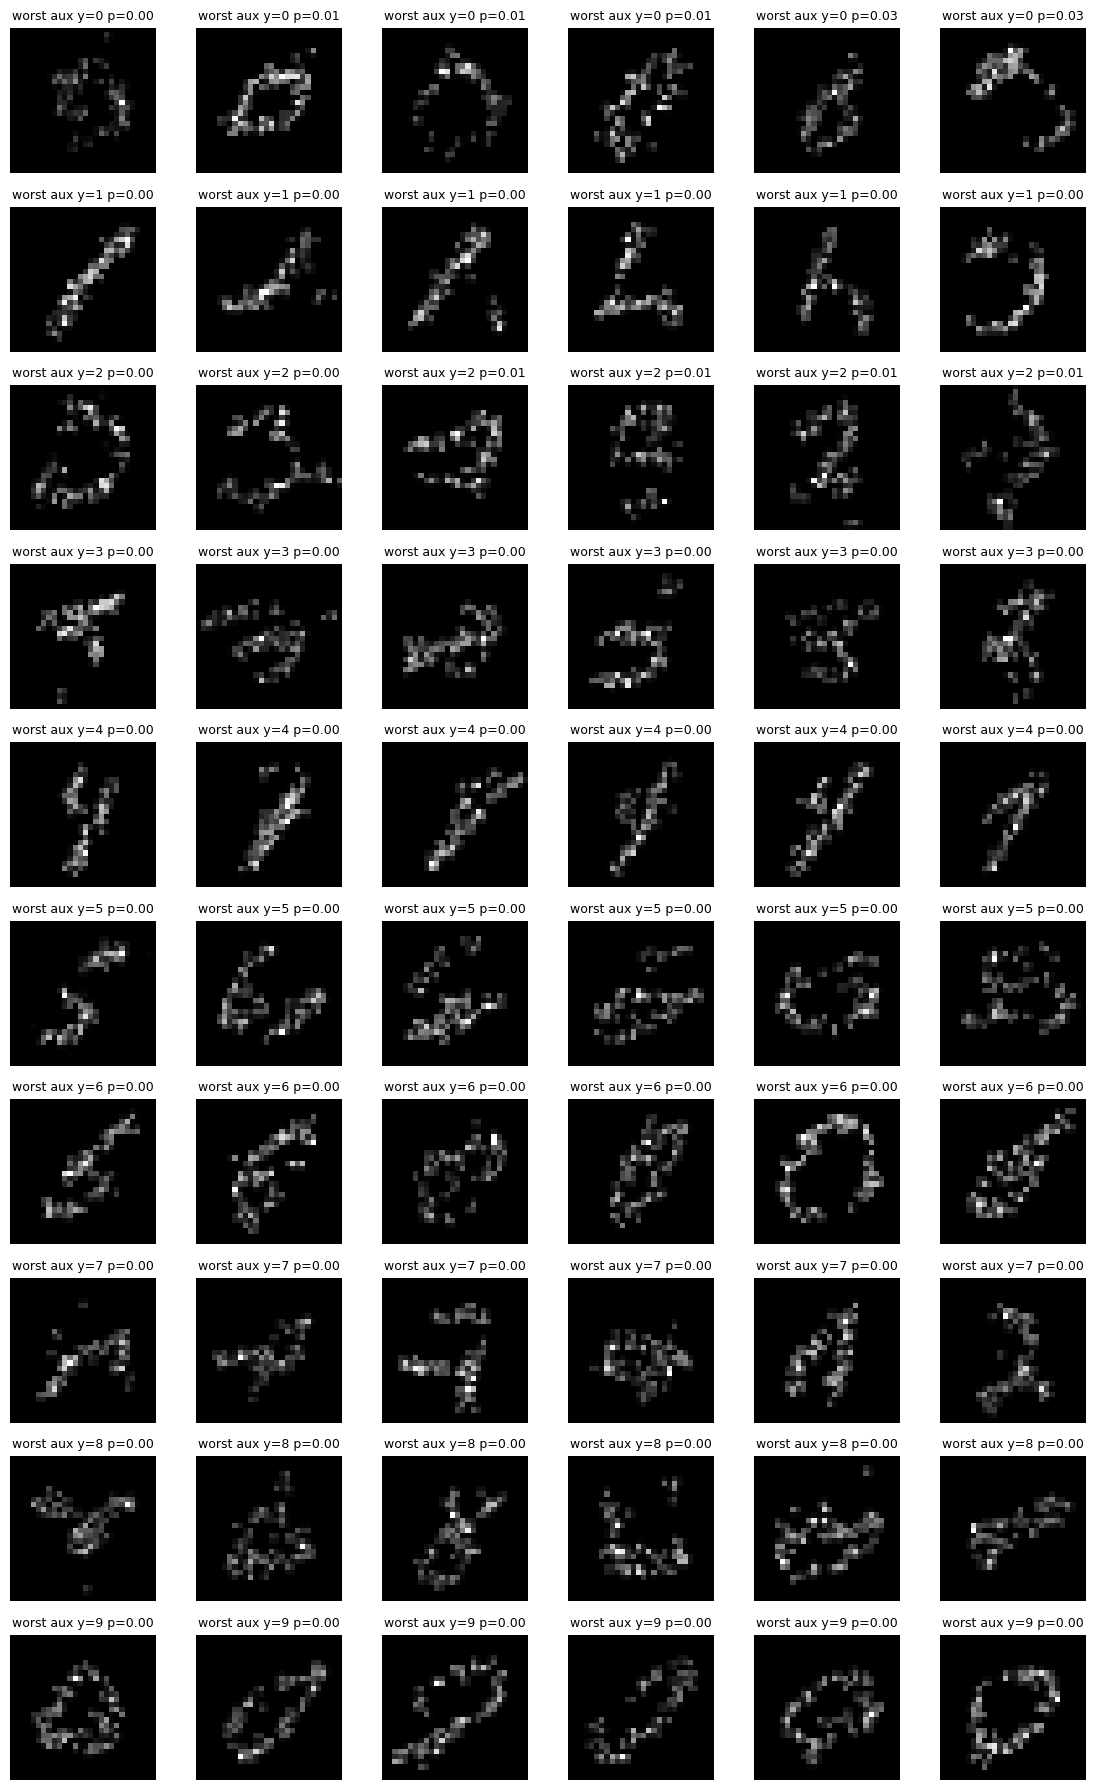

In [19]:
show_synthetic_examples(
    synthetic,
    count_per_class=VISUAL_DIAGNOSTIC_SAMPLES_PER_CLASS,
    title_prefix='best aux',
    selection='best',
    score_values=aux_target_probability,
)

show_synthetic_examples(
    synthetic,
    count_per_class=VISUAL_DIAGNOSTIC_SAMPLES_PER_CLASS,
    title_prefix='worst aux',
    selection='worst',
    score_values=aux_target_probability,
)


## Evaluation

We reuse the same evaluation function as Example 6.  The auxiliary classifier above is used only for reporting the classifier-based accuracy metric; generation itself is entirely score-based.


In [20]:
metrics = evaluate_generation_metrics(
    eval_classifier,
    synthetic,
    real_test_pc,
    real_test_images,
    real_test_labels,
    cas_epochs=CAS_EPOCHS,
    cas_batch_size=CAS_BATCH_SIZE,
    cas_lr=CAS_LR,
    cas_image_scale=CAS_IMAGE_SCALE,
    sinkhorn_epsilon=SINKHORN_EPSILON,
    sinkhorn_iterations=SINKHORN_ITERATIONS,
    sinkhorn_subsample_per_class=SINKHORN_SUBSAMPLE_PER_CLASS,
    device=DEVICE,
    rng=np.random.default_rng(SEED),
    verbose=True,
)

summary = {
    'aux_point_cloud_classifier_accuracy': metrics['g_accuracy'],
    'aux_point_cloud_mean_target_probability': metrics['g_mean_target_probability'],
    'cas_accuracy': metrics['cas_accuracy'],
    'cas_image_scale': metrics.get('cas_image_scale', np.nan),
    'one_nn_accuracy_macro': metrics['one_nn_accuracy_macro'],
    'coverage_macro': metrics['coverage_macro'],
    'mean_real_to_generated_sinkhorn_macro': metrics['mean_real_to_generated_sinkhorn_macro'],
    'mean_generated_to_real_sinkhorn_macro': metrics['mean_generated_to_real_sinkhorn_macro'],
    'mean_generated_diversity_macro': metrics['mean_generated_diversity_macro'],
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['value']
summary_df



[CAS] epoch 001/010: train loss = 2.0062, train acc = 0.2697
[CAS] epoch 002/010: train loss = 1.2449, train acc = 0.5838
[CAS] epoch 003/010: train loss = 0.8754, train acc = 0.7096
[CAS] epoch 004/010: train loss = 0.7191, train acc = 0.7599
[CAS] epoch 005/010: train loss = 0.6371, train acc = 0.7857
[CAS] epoch 006/010: train loss = 0.6214, train acc = 0.7923
[CAS] epoch 007/010: train loss = 0.5591, train acc = 0.8176
[CAS] epoch 008/010: train loss = 0.5343, train acc = 0.8233
[CAS] epoch 009/010: train loss = 0.5272, train acc = 0.8242
[CAS] epoch 010/010: train loss = 0.4996, train acc = 0.8334


,value
aux_point_cloud_classifier_accuracy,0.607000
aux_point_cloud_mean_target_probability,0.488126
cas_accuracy,0.831390
cas_image_scale,784.000000
one_nn_accuracy_macro,0.625000
coverage_macro,0.523438
mean_real_to_generated_sinkhorn_macro,0.003890
mean_generated_to_real_sinkhorn_macro,0.004482
mean_generated_diversity_macro,0.004331


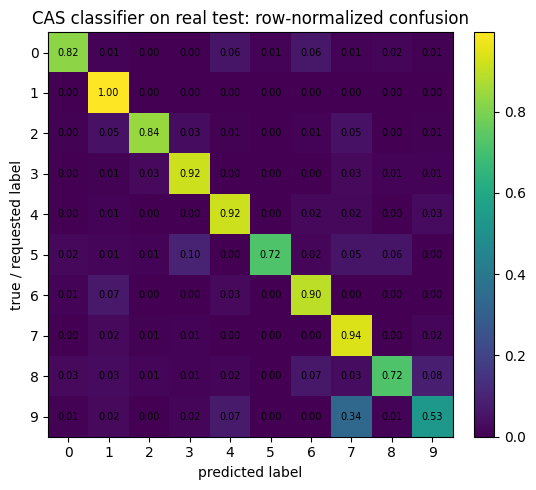

In [21]:
cas_test_metrics = metrics['cas_details'].get('test_metrics')
if cas_test_metrics is not None:
    cas_confusion_true = confusion_matrix_from_predictions(
        real_test_labels,
        cas_test_metrics['predictions'],
        num_classes=10,
        normalize='true',
    )
    plot_confusion_matrix(cas_confusion_true, title='CAS classifier on real test: row-normalized confusion')
else:
    cas_confusion_true = None


### Real-trained image classifier diagnostic

CAS trains on generated images and tests on real images.  The reverse diagnostic below trains the same small CNN on real MNIST images and evaluates it on generated images.  This helps identify which generated classes look like their requested labels to a classifier that only saw real data.


[CAS] epoch 001/008: train loss = 0.8200, train acc = 0.7478, val loss = 0.2899, val acc = 0.9164
[CAS] epoch 002/008: train loss = 0.2431, train acc = 0.9306, val loss = 0.1907, val acc = 0.9448
[CAS] epoch 003/008: train loss = 0.1794, train acc = 0.9474, val loss = 0.2045, val acc = 0.9398
[CAS] epoch 004/008: train loss = 0.1470, train acc = 0.9570, val loss = 0.1119, val acc = 0.9688
[CAS] epoch 005/008: train loss = 0.1239, train acc = 0.9626, val loss = 0.1080, val acc = 0.9684
[CAS] epoch 006/008: train loss = 0.1109, train acc = 0.9667, val loss = 0.0930, val acc = 0.9728
[CAS] epoch 007/008: train loss = 0.0983, train acc = 0.9711, val loss = 0.0983, val acc = 0.9698
[CAS] epoch 008/008: train loss = 0.0924, train acc = 0.9717, val loss = 0.1075, val acc = 0.9696
real-trained classifier accuracy on generated images = 0.5574


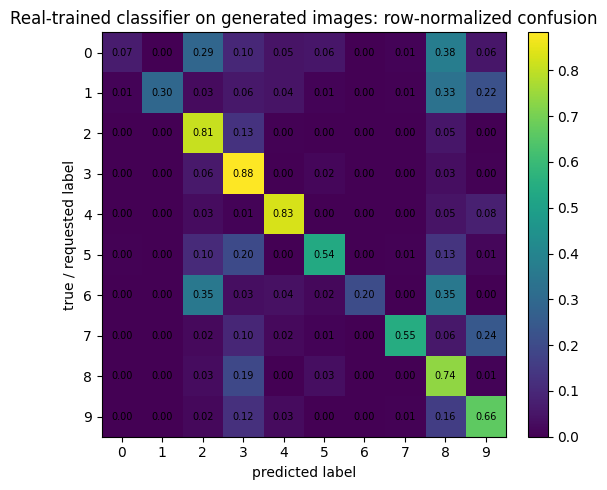

In [22]:
if RUN_REAL_TRAINED_IMAGE_DIAGNOSTIC:
    real_image_classifier = SmallMnistCNN()
    real_image_history = train_image_classifier(
        real_image_classifier,
        rescale_images_for_classifier(train_images, CAS_IMAGE_SCALE),
        train_labels,
        val_images=rescale_images_for_classifier(val_images, CAS_IMAGE_SCALE),
        val_labels=val_labels,
        epochs=REAL_IMAGE_CLASSIFIER_EPOCHS,
        batch_size=REAL_IMAGE_CLASSIFIER_BATCH_SIZE,
        lr=REAL_IMAGE_CLASSIFIER_LR,
        device=DEVICE,
        verbose=True,
    )
    real_on_generated_metrics = evaluate_image_classifier(
        real_image_classifier,
        rescale_images_for_classifier(synthetic.images, CAS_IMAGE_SCALE),
        synthetic.labels,
        batch_size=REAL_IMAGE_CLASSIFIER_BATCH_SIZE,
        device=DEVICE,
    )
    real_generated_confusion_true = confusion_matrix_from_predictions(
        synthetic.labels,
        real_on_generated_metrics['predictions'],
        num_classes=10,
        normalize='true',
    )
    real_generated_logits = real_on_generated_metrics['logits']
    real_generated_probs = _softmax_np(real_generated_logits)
    real_generated_target_probability = real_generated_probs[np.arange(len(synthetic.labels)), synthetic.labels]
    print('real-trained classifier accuracy on generated images =', real_on_generated_metrics['accuracy'])
    plot_confusion_matrix(
        real_generated_confusion_true,
        title='Real-trained classifier on generated images: row-normalized confusion',
    )
else:
    real_image_classifier = None
    real_image_history = None
    real_on_generated_metrics = None
    real_generated_target_probability = None


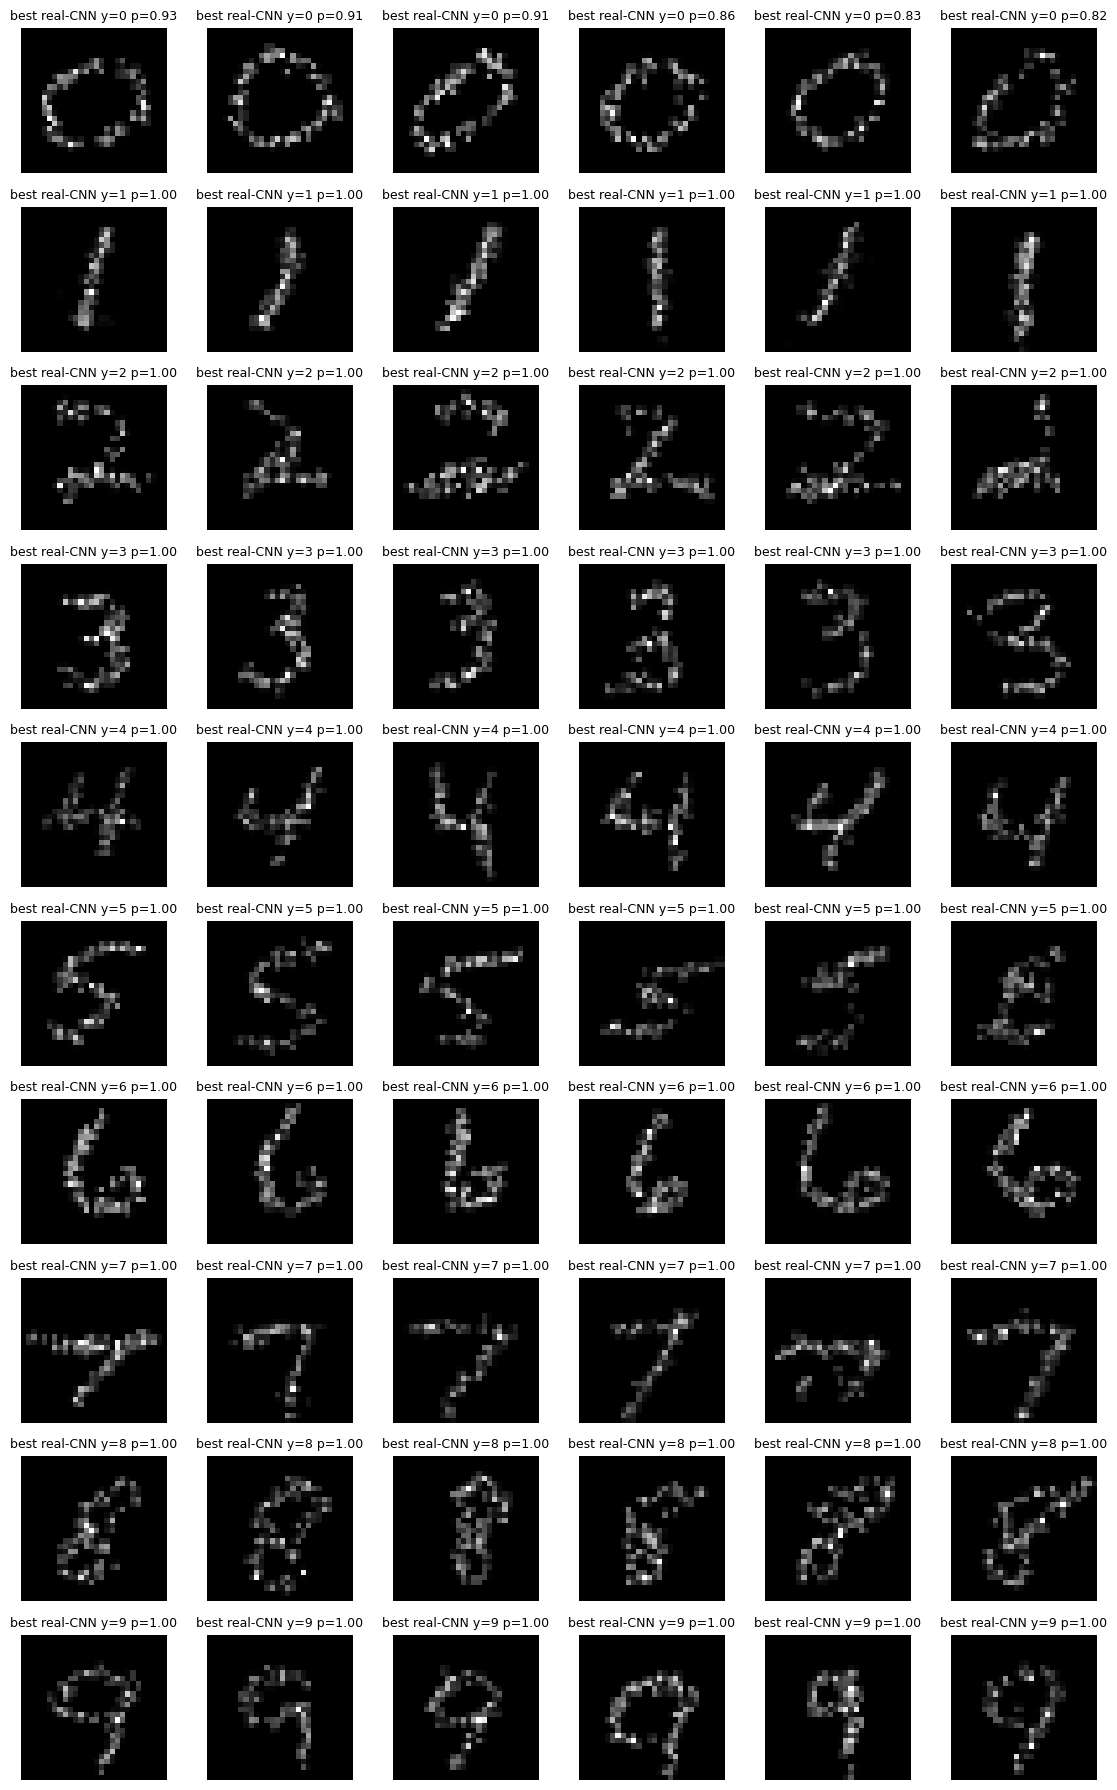

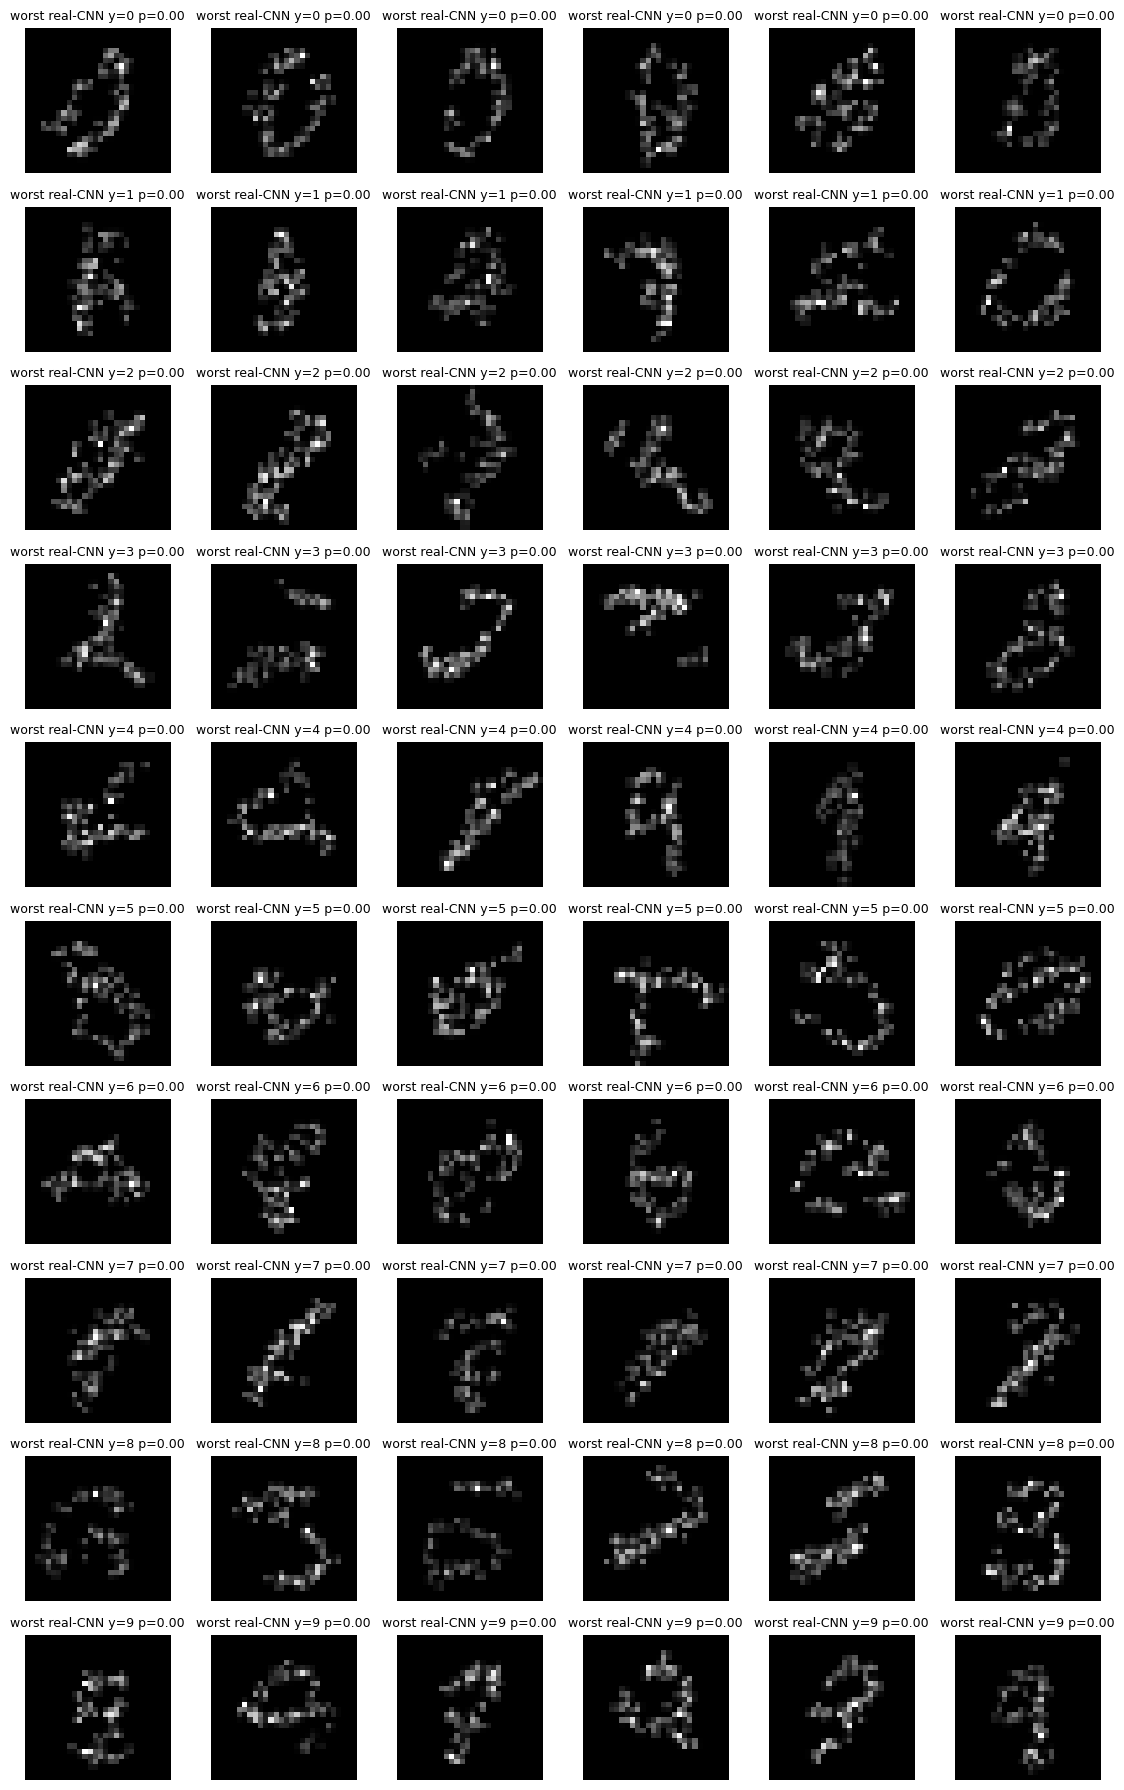

In [23]:
if real_generated_target_probability is not None:
    show_synthetic_examples(
        synthetic,
        count_per_class=VISUAL_DIAGNOSTIC_SAMPLES_PER_CLASS,
        title_prefix='best real-CNN',
        selection='best',
        score_values=real_generated_target_probability,
    )
    show_synthetic_examples(
        synthetic,
        count_per_class=VISUAL_DIAGNOSTIC_SAMPLES_PER_CLASS,
        title_prefix='worst real-CNN',
        selection='worst',
        score_values=real_generated_target_probability,
    )


In [24]:
per_label_df = pd.DataFrame(metrics['per_label']).T.sort_index()
per_label_df.index.name = 'label'
per_label_df

,one_nn_accuracy,coverage,mean_real_to_generated_sinkhorn,mean_generated_to_real_sinkhorn,mean_generated_diversity
label,,,,,
0,0.578125,0.531250,0.004648,0.004920,0.005212
1,0.734375,0.437500,0.000940,0.002465,0.001801
2,0.664062,0.515625,0.005807,0.006316,0.005656
3,0.648438,0.468750,0.004298,0.004652,0.004586
4,0.445312,0.609375,0.003172,0.003569,0.003756
5,0.664062,0.500000,0.005826,0.006368,0.006283
6,0.679688,0.562500,0.004109,0.004382,0.004018
7,0.593750,0.531250,0.003146,0.003965,0.003938
8,0.656250,0.531250,0.004408,0.004738,0.004459


## Reading the results

A reasonable first comparison against Example 6 is:

1. Keep the **same data split**, **same `top_k` representation**, and **same evaluation protocol**.
2. Compare the new score-based generator to the Example 6 `h`-transform generator on:
   - auxiliary classifier accuracy,
   - CAS,
   - 1-NN accuracy,
   - coverage,
   - Sinkhorn distances.
3. Then vary:
   - `MASS_SAMPLING_MODE` (`'bank'` vs `'truncated_poisson_dirichlet'`),
   - `SCORE_PROJECTION`,
   - `HORIZON`,
   - and the sampling schedule for `tau`.

Because the denoising target is explicit, notebook 7 removes the terminal Monte Carlo drift estimation entirely and learns the reverse drift directly through the score network.
